# Null Space Analysis

This notebook will extract and analyze neuron spiking data from NWB files.


In [40]:
import os
from pathlib import Path
from pynwb import NWBHDF5IO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up paths
data_root = Path("/Users/jundazhu/SBCAT/000469")


## All Functions

All functions are defined below, organized by category:
- **Trial Selection**: Select trials by load, correctness, probe in/out, or indices
- **File Listing**: List and select NWB files
- **Data Extraction**: Extract spike data and trial information from NWB files
- **DataFrame Creation**: Convert extraction results to DataFrames
- **Spike Segmentation**: Segment spikes by trials, aligned to specific events
- **Workflow**: Process single or multiple sessions

In [41]:
def select_trials_by_load(trials_df, load_values):
    """
    Select trials by memory load values (session-level).
    Args:
        trials_df: DataFrame with trial info
        load_values: int or list of int (e.g., 1, or [1,3])
    Returns:
        selected_trials_df: Filtered DataFrame
        selected_indices: np.array of row indices selected
    """
    if 'loads' not in trials_df.columns:
        raise ValueError("trials_df must have a 'loads' column")
    if not isinstance(load_values, (list, tuple, np.ndarray)):
        load_values = [load_values]
    mask = trials_df['loads'].isin(load_values)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices

def select_trials_by_correctness(trials_df, correct_only=True):
    """
    Select trials by correctness.
    Args:
        trials_df: DataFrame
        correct_only: bool
    Returns:
        selected_trials_df: Filtered DataFrame
        selected_indices: np.array of selected
    """
    if 'response_accuracy' not in trials_df.columns:
        raise ValueError("trials_df must have a 'response_accuracy' column")
    mask = (trials_df['response_accuracy'] == 1) if correct_only else (trials_df['response_accuracy'] != 1)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices

def select_trials_by_probe_in_out(trials_df, probe_in_out):
    """
    Select trials by probe in/out status.
    Args:
        trials_df: DataFrame
        probe_in_out: 'in' or 'out'
    Returns:
        selected_trials_df: Filtered DataFrame
        selected_indices: np.array of indices
    """
    if 'probe_in_out' not in trials_df.columns:
        raise ValueError("trials_df must have a 'probe_in_out' column")
    mask = (trials_df['probe_in_out'] == probe_in_out)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices

def select_trials_by_indices(trials_df, trial_indices):
    """
    Select trials by explicit trial indices.
    Args:
        trials_df: DataFrame
        trial_indices: list/array of 0-based trial indices
    Returns:
        selected_trials_df: Filtered DataFrame
        selected_indices: np.array of indices
    """
    selected_indices = np.array(trial_indices)
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices

def list_available_files(data_dir, session_filter=None):
    """List all available NWB files with indices for selection.
    Args:
        data_dir: path object or string to root dir
        session_filter: 'ses-1', 'ses-2', or None
    Returns:
        files: list of Path
    """
    files = sorted(data_dir.rglob("*.nwb"))
    if session_filter in ["ses-1", "ses-2"]:
        files = [f for f in files if session_filter in f.name]
        print(f"Found {len(files)} NWB files (session filter = {session_filter}):\n")
    else:
        print(f"Found {len(files)} NWB files:\n")
    for i, f in enumerate(files):
        rel_path = f.relative_to(data_dir)
        print(f"{i:3d}. {rel_path}")
    return files

def extract_spike_data(filepath, include_waveforms=False, quality_filters=None, include_trials=True):
    """
    Extract spike data from an NWB file.
    Args:
        filepath: Path object or string for file.
        include_waveforms: bool
        quality_filters: dict
        include_trials: bool
    Returns:
        dict with
          - 'filepath'
          - 'subject_id'
          - 'session_id'
          - 'units': list of dict
          - 'trials': DataFrame or None
    """
    filepath = Path(filepath)
    # Subject/session from file name
    parts = filepath.stem.split('_')
    subject_id = None
    session_id = None
    for part in parts:
        if part.startswith('sub-'):
            subject_id = int(part.split('-')[1])
        elif part.startswith('ses-'):
            session_id = int(part.split('-')[1])
    result = {
        'filepath': str(filepath),
        'subject_id': subject_id,
        'session_id': session_id,
        'units': []
    }
    try:
        with NWBHDF5IO(str(filepath), mode="r", load_namespaces=True) as io:
            nwbf = io.read()
            # trials
            if include_trials and nwbf.trials is not None:
                try:
                    trials_df = nwbf.trials.to_dataframe()
                    result['trials'] = trials_df
                except Exception as e:
                    print(f"Warning: Could not extract trials from {filepath.name}: {e}")
                    result['trials'] = None
            else:
                result['trials'] = None
            if nwbf.units is None:
                print(f"Warning: No units found in {filepath.name}")
                return result
            units_df = nwbf.units.to_dataframe()
            electrodes_df = nwbf.electrodes.to_dataframe() if nwbf.electrodes is not None else None
            for unit_idx in units_df.index:
                unit_data = {
                    'unit_id': int(unit_idx),
                    'spike_times': None,
                    'electrode_idx': None,
                    'cluster_id': None,
                    'mean_snr': None,
                    'peak_snr': None,
                    'isolation_distance': None,
                    'mean_proj_dist': None,
                    'n_spikes': 0,
                    'brain_region': None
                }
                # spike times
                try:
                    spike_times = np.array(nwbf.units['spike_times'][unit_idx][:])
                    unit_data['spike_times'] = spike_times
                    unit_data['n_spikes'] = len(spike_times)
                except Exception as e:
                    print(f"Warning: Could not extract spike times for unit {unit_idx}: {e}")
                    continue
                # electrode info
                if 'electrodes' in units_df.columns:
                    try:
                        electrode_info = units_df.loc[unit_idx, 'electrodes']
                        if hasattr(electrode_info, 'index'):
                            unit_data['electrode_idx'] = int(electrode_info.index[0]) if len(electrode_info.index) > 0 else None
                        else:
                            unit_data['electrode_idx'] = int(electrode_info) if pd.notna(electrode_info) else None
                        if unit_data['electrode_idx'] is not None and electrodes_df is not None:
                            if 'location' in electrodes_df.columns:
                                unit_data['brain_region'] = electrodes_df.loc[unit_data['electrode_idx'], 'location']
                    except Exception:
                        pass
                # quality metrics
                if 'clusterID_orig' in units_df.columns:
                    unit_data['cluster_id'] = units_df.loc[unit_idx, 'clusterID_orig']
                if 'waveforms_mean_snr' in units_df.columns:
                    unit_data['mean_snr'] = units_df.loc[unit_idx, 'waveforms_mean_snr']
                if 'waveforms_peak_snr' in units_df.columns:
                    unit_data['peak_snr'] = units_df.loc[unit_idx, 'waveforms_peak_snr']
                if 'waveforms_isolation_distance' in units_df.columns:
                    unit_data['isolation_distance'] = units_df.loc[unit_idx, 'waveforms_isolation_distance']
                if 'waveforms_mean_proj_dist' in units_df.columns:
                    unit_data['mean_proj_dist'] = units_df.loc[unit_idx, 'waveforms_mean_proj_dist']
                # filter
                if quality_filters is not None:
                    skip_unit = False
                    if 'min_snr' in quality_filters and unit_data['mean_snr'] is not None:
                        if unit_data['mean_snr'] < quality_filters['min_snr']:
                            skip_unit = True
                    if 'min_isolation_distance' in quality_filters and unit_data['isolation_distance'] is not None:
                        if unit_data['isolation_distance'] < quality_filters['min_isolation_distance']:
                            skip_unit = True
                    if 'min_n_spikes' in quality_filters:
                        if unit_data['n_spikes'] < quality_filters['min_n_spikes']:
                            skip_unit = True
                    if skip_unit:
                        continue
                # waveforms
                if include_waveforms and 'waveforms' in units_df.columns:
                    try:
                        waveforms = np.array(nwbf.units['waveforms'][unit_idx][:])
                        unit_data['waveforms'] = waveforms
                    except Exception:
                        pass
                result['units'].append(unit_data)
    except Exception as e:
        print(f"Error processing {filepath.name}: {e}")
        import traceback
        traceback.print_exc()
    return result

def batch_extract_spike_data(filepaths, include_waveforms=False, quality_filters=None, include_trials=True, verbose=True):
    """
    Extract spike data for multiple NWB files.
    Args:
        filepaths: list of file paths or Path objects
        include_waveforms: bool
        quality_filters: dict
        include_trials: bool
        verbose: bool
    Returns:
        list of extract_spike_data results
    """
    if isinstance(filepaths, (str, Path)):
        filepaths = [filepaths]
    results = []
    n_files = len(filepaths)
    for i, filepath in enumerate(filepaths, 1):
        if verbose:
            print(f"Processing file {i}/{n_files}: {Path(filepath).name}")
        result = extract_spike_data(
            filepath, 
            include_waveforms=include_waveforms,
            quality_filters=quality_filters,
            include_trials=include_trials
        )
        results.append(result)
        if verbose:
            n_units = len(result['units'])
            n_trials = len(result['trials']) if result['trials'] is not None else 0
            print(f"  Extracted {n_units} units, {n_trials} trials")
    return results

def create_spike_dataframe(extraction_results):
    """
    Convert extraction results to DataFrame: one row per unit.
    Args:
        extraction_results: list of dict
    Returns:
        DataFrame
    """
    rows = []
    for result in extraction_results:
        for unit in result['units']:
            row = {
                'subject_id': result['subject_id'],
                'session_id': result['session_id'],
                'filepath': result['filepath'],
                'unit_id': unit['unit_id'],
                'n_spikes': unit['n_spikes'],
                'electrode_idx': unit['electrode_idx'],
                'brain_region': unit['brain_region'],
                'cluster_id': unit['cluster_id'],
                'mean_snr': unit['mean_snr'],
                'peak_snr': unit['peak_snr'],
                'isolation_distance': unit['isolation_distance'],
                'mean_proj_dist': unit['mean_proj_dist'],
                'spike_times': unit['spike_times']
            }
            rows.append(row)
    return pd.DataFrame(rows)

def extract_trials_dataframe(extraction_results):
    """
    Extract trial info from extraction results.
    Args:
        extraction_results: list of dict
    Returns:
        DataFrame with trial info, subject/session/filepath columns
    """
    trial_rows = []
    for result in extraction_results:
        if result['trials'] is not None:
            trials_df = result['trials'].copy()
            trials_df['subject_id'] = result['subject_id']
            trials_df['session_id'] = result['session_id']
            trials_df['filepath'] = result['filepath']
            trial_rows.append(trials_df)
    if len(trial_rows) == 0:
        return pd.DataFrame()
    return pd.concat(trial_rows, ignore_index=True)

def segment_spikes_by_trials(spike_times, trials_df, align_to='start_time', time_window=None):
    """
    Segment spikes by trials, aligned to align_to column.
    Args:
        spike_times: 1D array
        trials_df: DataFrame
        align_to: str, column to align to
        time_window: (start_offset, end_offset) or None
    Returns:
        list of arrays, one per trial (aligned)
    """
    segmented_spikes = []
    for trial_idx, trial in trials_df.iterrows():
        if align_to in trial and pd.notna(trial[align_to]) and trial[align_to] > 0:
            alignment_point = trial[align_to]
        elif 'start_time' in trial:
            alignment_point = trial['start_time']
        else:
            segmented_spikes.append(np.array([]))
            continue
        if time_window is not None:
            window_start = alignment_point + time_window[0]
            window_end = alignment_point + time_window[1]
        else:
            window_start = trial.get('start_time', alignment_point)
            window_end = trial.get('stop_time', alignment_point + 10.0)
        mask = (spike_times >= window_start) & (spike_times < window_end)
        trial_spikes = spike_times[mask]
        aligned_spikes = trial_spikes - alignment_point
        segmented_spikes.append(aligned_spikes)
    return segmented_spikes

def segment_spikes_by_selected_trials(spike_times, trials_df, selected_trial_indices=None,
                                      align_to='start_time', time_window=None):
    """
    Segment spikes for selected trials, as above but possibly a subset.
    Args:
        spike_times: 1D array
        trials_df: DataFrame
        selected_trial_indices: indices or None
        align_to: str
        time_window: tuple or None
    Returns:
        list of arrays, one per selected trial (aligned)
    """
    if selected_trial_indices is not None:
        selected_trials_df = trials_df.iloc[selected_trial_indices].copy()
        selected_trials_df = selected_trials_df.reset_index(drop=True)
    else:
        selected_trials_df = trials_df
    return segment_spikes_by_trials(
        spike_times,
        selected_trials_df,
        align_to=align_to,
        time_window=time_window
    )

def process_session(filepath, selected_trial_indices=None, align_to='start_time', time_window=None, 
                     trial_groups=None, group_labels=None):
    """
    Process a single session (file); returns DataFrame of units, with segmented spikes.
    Args:
        filepath: string or Path
        selected_trial_indices: indices, or None
        align_to: str
        time_window: tuple
        trial_groups: list of ndarrays or None (group indices within selected_trial_indices)
        group_labels: list of str or None
    Returns:
        session_df: DataFrame (rows = units)
    """
    result = extract_spike_data(filepath, include_trials=True)
    if result['trials'] is None or len(result['trials']) == 0:
        print(f"Warning: No trials found in {Path(filepath).name}")
        return None
    if len(result['units']) == 0:
        print(f"Warning: No units found in {Path(filepath).name}")
        return None
    trials_df = result['trials'].copy().reset_index(drop=True)
    if selected_trial_indices is None:
        selected_trial_indices = np.arange(len(trials_df))
    if trial_groups is not None and group_labels is None:
        group_labels = [f'group{i}' for i in range(len(trial_groups))]
    unit_rows = []
    for unit in result['units']:
        spike_times = unit['spike_times']
        segmented = segment_spikes_by_selected_trials(
            spike_times,
            trials_df,
            selected_trial_indices=selected_trial_indices,
            align_to=align_to,
            time_window=time_window
        )
        row = {
            'subject_id': result['subject_id'],
            'session_id': result['session_id'],
            'filepath': result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist'],
            'spike_times': spike_times,
            'segmented_spikes': segmented,
            'n_trials': len(segmented),
            'selected_trial_indices': selected_trial_indices
        }
        if trial_groups is not None:
            row['trial_groups'] = trial_groups
            row['group_labels'] = group_labels
        unit_rows.append(row)
    session_df = pd.DataFrame(unit_rows)
    return session_df

def create_unit_metadata_df(extraction_result):
    """
    DataFrame of all metadata for each unit (no spikes).
    Args:
        extraction_result: result from extract_spike_data
    Returns:
        DataFrame
    """
    unit_rows = []
    for unit in extraction_result['units']:
        row = {
            'subject_id': extraction_result['subject_id'],
            'session_id': extraction_result['session_id'],
            'filepath': extraction_result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist']
        }
        unit_rows.append(row)
    return pd.DataFrame(unit_rows)

def process_multiple_sessions(filepaths, trial_selection_func=None, align_to='start_time', time_window=None, 
                              trial_groups_dict=None, group_labels=None, verbose=True):
    """
    Process multiple sessions/filepaths; returns a compiled DataFrame.
    Args:
        filepaths: list of filepaths
        trial_selection_func: function (trials_df, filepath) -> indices, or None
        align_to, time_window: see process_session
        trial_groups_dict: dict mapping to group arrays
        group_labels: optional list of str for group_labels
        verbose: bool
    Returns:
        compiled_df: DataFrame
    """
    all_session_dfs = []
    for i, filepath in enumerate(filepaths, 1):
        if verbose:
            print(f"Processing session {i}/{len(filepaths)}: {Path(filepath).name}")
        result = extract_spike_data(filepath, include_trials=True, include_waveforms=False)
        if result['trials'] is None or len(result['trials']) == 0:
            if verbose:
                print(f"  Skipping: No trials found")
            continue
        trials_df = result['trials'].copy().reset_index(drop=True)
        if trial_selection_func is not None:
            selected_trial_indices = trial_selection_func(trials_df, filepath)
        else:
            selected_trial_indices = None
        if verbose and selected_trial_indices is not None:
            print(f"  Selected {len(selected_trial_indices)} trials")
        trial_groups = None
        if trial_groups_dict is not None:
            filepath_str = str(filepath)
            filepath_path = Path(filepath)
            if filepath_str in trial_groups_dict:
                trial_groups = trial_groups_dict[filepath_str]
            elif filepath_path in trial_groups_dict:
                trial_groups = trial_groups_dict[filepath_path]
            else:
                for key in trial_groups_dict:
                    if str(key) == filepath_str or str(key) == str(filepath_path):
                        trial_groups = trial_groups_dict[key]
                        break
                    if Path(key).name == filepath_path.name:
                        trial_groups = trial_groups_dict[key]
                        break
        session_df = process_session(
            filepath,
            selected_trial_indices=selected_trial_indices,
            align_to=align_to,
            time_window=time_window,
            trial_groups=trial_groups,
            group_labels=group_labels
        )
        if session_df is not None:
            all_session_dfs.append(session_df)
            if verbose:
                print(f"  Extracted {len(session_df)} units")
                if trial_groups is not None:
                    print(f"  Stored {len(trial_groups)} trial groups")
    if len(all_session_dfs) == 0:
        print("Warning: No sessions processed successfully")
        return pd.DataFrame()
    compiled_df = pd.concat(all_session_dfs, ignore_index=True)
    if verbose:
        print(f"\n✓ Compiled {len(compiled_df)} units from {len(all_session_dfs)} sessions")
        if trial_groups_dict is not None:
            print(f"  Group info stored in compiled_df columns")
    return compiled_df

def collapse_hemispheres(compiled_df, inplace=False):
    """
    Collapse left/right hemispheres for brain_region. Adds 'brain_region_collapsed' column.
    Args:
        compiled_df: DataFrame
        inplace: bool
    Returns:
        DataFrame with 'brain_region_collapsed'
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    df = compiled_df if inplace else compiled_df.copy()
    def collapse_region(region):
        if pd.isna(region) or region is None:
            return region
        region_str = str(region).strip()
        if region_str.lower().endswith('_left'):
            return region_str[:-5]
        elif region_str.lower().endswith('_right'):
            return region_str[:-6]
        else:
            return region_str
    df['brain_region_collapsed'] = df['brain_region'].apply(collapse_region)
    return df

def list_available_brain_regions(compiled_df, show_collapsed=True):
    """
    Print all unique regions (and collapsed regions, if requested).
    Args:
        compiled_df: DataFrame with 'brain_region'
        show_collapsed: bool
    Returns:
        (original_regions, collapsed_regions)
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    original_regions = compiled_df['brain_region'].dropna().unique()
    original_regions = sorted([str(r) for r in original_regions if r is not None])
    print("=== Available Brain Regions ===")
    print(f"\nOriginal regions ({len(original_regions)}):")
    for i, region in enumerate(original_regions, 1):
        count = len(compiled_df[compiled_df['brain_region'] == region])
        print(f"  {i:2d}. {region:30s} ({count} units)")
    if show_collapsed:
        if 'brain_region_collapsed' not in compiled_df.columns:
            df_temp = collapse_hemispheres(compiled_df.copy())
        else:
            df_temp = compiled_df
        collapsed_regions = df_temp['brain_region_collapsed'].dropna().unique()
        collapsed_regions = sorted([str(r) for r in collapsed_regions if r is not None])
        print(f"\nCollapsed regions ({len(collapsed_regions)}):")
        for i, region in enumerate(collapsed_regions, 1):
            count = len(df_temp[df_temp['brain_region_collapsed'] == region])
            print(f"  {i:2d}. {region:30s} ({count} units)")
        return original_regions, collapsed_regions
    return original_regions, None

def select_units_by_brain_region(compiled_df, brain_regions, match_type='exact', use_collapsed=True):
    """
    Select units by brain region.
    Args:
        compiled_df: DataFrame
        brain_regions: str or list
        match_type: 'exact' or 'contains'
        use_collapsed: bool
    Returns:
        filtered_df: DataFrame
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    if use_collapsed:
        if 'brain_region_collapsed' not in compiled_df.columns:
            compiled_df = collapse_hemispheres(compiled_df.copy())
        region_col = 'brain_region_collapsed'
    else:
        region_col = 'brain_region'
    if isinstance(brain_regions, str):
        brain_regions = [brain_regions]
    if match_type == 'exact':
        mask = compiled_df[region_col].isin(brain_regions)
    elif match_type == 'contains':
        mask = compiled_df[region_col].astype(str).str.contains(
            '|'.join(brain_regions), case=False, na=False, regex=True
        )
    else:
        raise ValueError(f"Unknown match_type: {match_type}. Use 'exact' or 'contains'")
    filtered_df = compiled_df[mask].copy()
    return filtered_df

def assign_trial_conditions_per_unit(trials_df, encoding_epoch=1, 
                                     selected_trial_indices=None, n_conditions=5):
    """
    Assign each trial a 0-based condition index based on stimulus number (1..n_conditions).
    Ensures a fixed condition axis across sessions; missing/invalid IDs map to 0.
    Args:
        trials_df: DataFrame
        encoding_epoch: 1 or 3
        selected_trial_indices: indices or None
        n_conditions: total number of stimulus conditions (default 5)
    Returns:
        trial_conditions: np.array of length n_trials (0-based condition index)
    """
    pic_col = 'loadsEnc1_PicIDs' if encoding_epoch == 1 else 'loadsEnc3_PicIDs'
    trials_subset = trials_df.iloc[selected_trial_indices] if selected_trial_indices is not None else trials_df

    def map_pic_id(pic_id):
        if pd.isna(pic_id) or pic_id is None:
            return 0
        try:
            pid = int(pic_id)
        except Exception:
            return 0
        if pid <= 0:
            return 0
        idx = pid - 1
        # Clamp to configured condition count to avoid out-of-range indices
        return min(idx, n_conditions - 1)

    trial_conditions = np.array([map_pic_id(pic_id) for pic_id in trials_subset[pic_col]])
    return trial_conditions

def compute_mean_rate_hz(segmented_spikes, time_window):
    """
    Compute mean firing rate (Hz) across selected trials for one unit.
    Args:
        segmented_spikes: list of arrays, one per selected trial
        time_window: tuple (start, end) defining alignment window
    Returns:
        mean_rate_hz: float (spikes/sec), or np.nan if not computable
    """
    if time_window is None:
        return np.nan
    window_start, window_end = time_window
    window_duration = window_end - window_start
    if window_duration <= 0:
        return np.nan
    total_spikes = sum(len(trial) for trial in segmented_spikes)
    total_time = len(segmented_spikes) * window_duration
    if total_time <= 0:
        return np.nan
    return total_spikes / total_time


def build_firing_rate_matrix_per_unit(segmented_spikes, trial_conditions, n_conditions,
                                      bin_size=0.02, time_range=None):
    """
    Build a unit's per-condition × timebin matrix (1 vector).
    Args:
        segmented_spikes: list of arrays, one per trial
        trial_conditions: np.array, int index per trial
        n_conditions: int
        bin_size: float, seconds
        time_range: (start, end) or None
    Returns:
        row_vector: 1D np.array (n_conditions * n_bins)
        bin_edges: np.array
    """
    if time_range is None:
        all_times = []
        for trial_spikes in segmented_spikes:
            if len(trial_spikes) > 0:
                all_times.extend(trial_spikes)
        if len(all_times) == 0:
            time_range = (0, 1)
        else:
            time_range = (min(all_times), max(all_times))
    start_time, end_time = time_range
    n_bins = int(np.ceil((end_time - start_time) / bin_size))
    bin_edges = np.linspace(start_time, end_time, n_bins + 1)
    row_vector = np.zeros(n_conditions * n_bins)
    for cond_idx in range(n_conditions):
        cond_mask = trial_conditions == cond_idx
        cond_trial_indices = np.where(cond_mask)[0]
        if len(cond_trial_indices) == 0:
            continue
        trial_binned = []
        for trial_idx in cond_trial_indices:
            trial_spikes = segmented_spikes[trial_idx]
            if len(trial_spikes) > 0:
                counts, _ = np.histogram(trial_spikes, bins=bin_edges)
                trial_binned.append(counts)
            else:
                trial_binned.append(np.zeros(n_bins))
        if len(trial_binned) > 0:
            cond_mean = np.mean(trial_binned, axis=0)
            start_col = cond_idx * n_bins
            end_col = (cond_idx + 1) * n_bins
            row_vector[start_col:end_col] = cond_mean
    return row_vector, bin_edges

def process_session_condition_based(filepath, selected_trial_indices=None, align_to='start_time', 
                                    time_window=None, encoding_epoch=1,
                                    bin_size=0.01, selected_unit_ids=None, n_conditions=5,
                                    min_mean_rate_hz=None):
    """
    Process one session; returns condition-based firing rate matrix for units.
    Args:
        filepath: file
        selected_trial_indices: indices or None
        align_to: str (column in trials_df)
        time_window: tuple or None
        encoding_epoch: 1 or 3
        bin_size: float
        selected_unit_ids: list of (subject_id, session_id, unit_id) or None
        n_conditions: total number of stimulus conditions (fixed across sessions)
        min_mean_rate_hz: float or None; drop units with mean firing rate below threshold (Hz)
    Returns:
        matrix: np.array (n_units, n_conditions * n_bins)
        unit_info: DataFrame (includes mean_rate_hz for retained units)
        bin_edges: np.array
        column_labels: list of str
        condition_info: dict
    """
    result = extract_spike_data(filepath, include_trials=True)
    if result['trials'] is None or len(result['trials']) == 0:
        return None, None, None, None, None
    trials_df = result['trials'].copy().reset_index(drop=True)
    if selected_trial_indices is None:
        selected_trial_indices = np.arange(len(trials_df))
    if encoding_epoch == 1:
        pic_col = 'loadsEnc1_PicIDs'
    else:
        pic_col = 'loadsEnc3_PicIDs'

    # Compute trial conditions once for all units (same for all units in a session)
    trial_conditions = assign_trial_conditions_per_unit(
        trials_df,
        encoding_epoch=encoding_epoch,
        selected_trial_indices=selected_trial_indices,
        n_conditions=n_conditions
    )

    selected_unit_set = set(selected_unit_ids) if selected_unit_ids is not None else None
    unit_rows = []
    matrix_rows = []
    bin_edges = None
    for unit in result['units']:
        unit_identifier = (result['subject_id'], result['session_id'], unit['unit_id'])
        if selected_unit_set is not None and unit_identifier not in selected_unit_set:
            continue
        spike_times = unit['spike_times']
        segmented = segment_spikes_by_selected_trials(
            spike_times, trials_df, selected_trial_indices,
            align_to=align_to, time_window=time_window
        )
        mean_rate_hz = compute_mean_rate_hz(segmented, time_window)
        if min_mean_rate_hz is not None:
            if np.isnan(mean_rate_hz) or mean_rate_hz < min_mean_rate_hz:
                continue
        row_vector, bin_edges = build_firing_rate_matrix_per_unit(
            segmented, trial_conditions, n_conditions,
            bin_size=bin_size, time_range=time_window
        )
        matrix_rows.append(row_vector)
        unit_rows.append({
            'subject_id': result['subject_id'],
            'session_id': result['session_id'],
            'filepath': result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist'],
            'mean_rate_hz': mean_rate_hz
        })
    if len(matrix_rows) == 0:
        return None, None, None, None, None
    matrix = np.vstack(matrix_rows)
    unit_info = pd.DataFrame(unit_rows)
    n_bins = len(bin_edges) - 1 if bin_edges is not None else 0
    column_labels = []
    condition_info = {}
    for cond_idx in range(n_conditions):
        start_col = cond_idx * n_bins
        end_col = (cond_idx + 1) * n_bins
        condition_info[f'cond{cond_idx}'] = slice(start_col, end_col)
        for bin_idx in range(n_bins):
            column_labels.append(f'cond{cond_idx}_t{bin_idx}')
    return matrix, unit_info, bin_edges, column_labels, condition_info


## 1. load data

### all file list

In [42]:
# List available files and select by index, with optional session filter
# session_filter options:
#   'all'   -> list all files
#   'ses-1' -> only session 1 files
#   'ses-2' -> only session 2 files
session_filter = 'ses-2'  # change as needed: 'all', 'ses-1', or 'ses-2'

# Get all files from disk, applying session_filter inside list_available_files
if session_filter == 'all':
    all_files = list_available_files(data_root)
else:
    all_files = list_available_files(data_root, session_filter=session_filter)


Found 21 NWB files (session filter = ses-2):

  0. sub-1/sub-1_ses-2_ecephys+image.nwb
  1. sub-10/sub-10_ses-2_ecephys+image.nwb
  2. sub-11/sub-11_ses-2_ecephys+image.nwb
  3. sub-12/sub-12_ses-2_ecephys+image.nwb
  4. sub-13/sub-13_ses-2_ecephys+image.nwb
  5. sub-14/sub-14_ses-2_ecephys+image.nwb
  6. sub-15/sub-15_ses-2_ecephys+image.nwb
  7. sub-16/sub-16_ses-2_ecephys+image.nwb
  8. sub-17/sub-17_ses-2_ecephys+image.nwb
  9. sub-18/sub-18_ses-2_ecephys+image.nwb
 10. sub-19/sub-19_ses-2_ecephys+image.nwb
 11. sub-2/sub-2_ses-2_ecephys+image.nwb
 12. sub-20/sub-20_ses-2_ecephys+image.nwb
 13. sub-21/sub-21_ses-2_ecephys+image.nwb
 14. sub-3/sub-3_ses-2_ecephys+image.nwb
 15. sub-4/sub-4_ses-2_ecephys+image.nwb
 16. sub-5/sub-5_ses-2_ecephys+image.nwb
 17. sub-6/sub-6_ses-2_ecephys+image.nwb
 18. sub-7/sub-7_ses-2_ecephys+image.nwb
 19. sub-8/sub-8_ses-2_ecephys+image.nwb
 20. sub-9/sub-9_ses-2_ecephys+image.nwb


In [43]:
# Select files to process from already-filtered all_files
# If selected_indices is empty [], all files in all_files will be selected
selected_indices = []  # e.g., [0, 1, 2]; leave [] to use all files

if len(selected_indices) == 0:
    selected_files = all_files
    print(f"Selected all {len(selected_files)} files to process:")
else:
    selected_files = [all_files[i] for i in selected_indices]
    print(f"Selected {len(selected_files)} files to process (manual indices):")

for f in selected_files:
    print(f"  {f.relative_to(data_root)}")

Selected all 21 files to process:
  sub-1/sub-1_ses-2_ecephys+image.nwb
  sub-10/sub-10_ses-2_ecephys+image.nwb
  sub-11/sub-11_ses-2_ecephys+image.nwb
  sub-12/sub-12_ses-2_ecephys+image.nwb
  sub-13/sub-13_ses-2_ecephys+image.nwb
  sub-14/sub-14_ses-2_ecephys+image.nwb
  sub-15/sub-15_ses-2_ecephys+image.nwb
  sub-16/sub-16_ses-2_ecephys+image.nwb
  sub-17/sub-17_ses-2_ecephys+image.nwb
  sub-18/sub-18_ses-2_ecephys+image.nwb
  sub-19/sub-19_ses-2_ecephys+image.nwb
  sub-2/sub-2_ses-2_ecephys+image.nwb
  sub-20/sub-20_ses-2_ecephys+image.nwb
  sub-21/sub-21_ses-2_ecephys+image.nwb
  sub-3/sub-3_ses-2_ecephys+image.nwb
  sub-4/sub-4_ses-2_ecephys+image.nwb
  sub-5/sub-5_ses-2_ecephys+image.nwb
  sub-6/sub-6_ses-2_ecephys+image.nwb
  sub-7/sub-7_ses-2_ecephys+image.nwb
  sub-8/sub-8_ses-2_ecephys+image.nwb
  sub-9/sub-9_ses-2_ecephys+image.nwb


## 2. Unit and Trial Selection

For each session:
1. Extract unit metadata
2. Select units (e.g., by brain region)
3. Select trials (e.g., by correctness or load)
4. Build condition-based matrices (Section 3)

**Note:** Unit and trial selection happens per session, then matrices are compiled across sessions.


In [44]:
# Define unit selection criteria (applied per session in Section 3)
# Select multiple brain regions to include in the compiled matrix
# Later in Section 5.5, filter into source and target subsets for PCA
selected_brain_regions = None  # Set to None to use all units (then filter in Section 5.5)
# Or specify a list of brain regions, e.g., ['hippocampus', 'pre_supplementary_motor_area']
# Minimum mean firing rate (Hz) during maintenance; set to None to disable filtering
min_mean_rate_hz_maintenance = 1.0


# Define trial selection function: Correct trials AND load = 1
def select_correct_load1_trials(trials_df, filepath):
    """Select correct trials with load = 1 for this session."""
    # First select correct trials
    _, correct_indices = select_trials_by_correctness(trials_df, correct_only=True)
    
    # Then filter to load = 1
    correct_trials_df = trials_df.iloc[correct_indices]
    _, load1_indices_in_correct = select_trials_by_load(correct_trials_df, load_values=1)
    
    # Map back to original trial indices
    final_indices = correct_indices[load1_indices_in_correct]
    
    return final_indices


## 3. Build Firing Rate Matrices

Process sessions individually and build firing rate matrices with condition-based columns:
- **Projection epoch**: Aligned to maintenance onset, time window 0-2500 ms
- **Regression epoch**: Aligned to encoding 1 onset, time window 0-1000 ms
- Each row = one unit
- Each column = one time bin in one condition
- Conditions are based on stimulus numbers (1-5) from loadsEnc1_PicIDs/loadsEnc3_PicIDs
- To pool images from different subjects, we arbitrarily labeled the individual images of each subject as Images A–E. We then pooled the images with the same label across all subjects. Note that each subject saw a different set of pictures.
- Each value = mean spike count across trials in that condition for that unit in that bin
- Matrices are compiled vertically across sessions (all units have same number of conditions)


In [45]:
# Process sessions individually and build firing rate matrices with condition-based columns
# Projection epoch: aligned to maintenance onset, time window 0-2500 ms
# Each column = one time bin in one condition (conditions based on stimulus numbers 1-5)
print("Processing projection epoch (0-2500 ms relative to maintenance onset) per session...")
print("Using condition-based matrix: each column = condition × time bin")

session_matrices_projection = []
session_unit_infos_projection = []
column_labels_list_projection = []
condition_info_list_projection = []
total_units_projection = 0

for i, filepath in enumerate(selected_files, 1):
    print(f"\nProcessing session {i}/{len(selected_files)}: {Path(filepath).name}")
    
    # Step 1: Extract unit metadata for this session
    result = extract_spike_data(filepath, include_trials=True)
    unit_metadata = create_unit_metadata_df(result)
    
    # Step 2: Select units for this session (e.g., by brain region)
    if selected_brain_regions is not None:
        selected_units = select_units_by_brain_region(
            unit_metadata, 
            brain_regions=selected_brain_regions,
            match_type='exact',
            use_collapsed=True
        )
        selected_unit_ids = [(row['subject_id'], row['session_id'], row['unit_id']) 
                             for _, row in selected_units.iterrows()]
        print(f"  Selected {len(selected_unit_ids)} units from {selected_brain_regions}")
    else:
        selected_unit_ids = None
        print(f"  Using all {len(unit_metadata)} units")
    
    # Step 3: Select trials for this session (e.g., by correctness)
    trials_df = result['trials']
    if trials_df is None or len(trials_df) == 0:
        print(f"  Skipping: No trials found")
        continue
    
    selected_trial_indices = select_correct_load1_trials(trials_df, filepath)
    print(f"  Selected {len(selected_trial_indices)} trials (correct + load=1)")
    
    # Step 4: Build matrices for this session (selected units + selected trials)
    rate_threshold = min_mean_rate_hz_maintenance
    matrix, unit_info, bin_edges, column_labels, condition_info = process_session_condition_based(
        filepath,
        selected_unit_ids=selected_unit_ids,
        selected_trial_indices=selected_trial_indices,
        align_to='timestamps_Maintenance',
        time_window=(0, 2.5),
        encoding_epoch=1,
        bin_size=0.01,
        min_mean_rate_hz=rate_threshold
    )
    units_before_rate = len(selected_unit_ids) if selected_unit_ids is not None else len(unit_metadata)
    if rate_threshold is not None:
        kept_units = len(unit_info) if unit_info is not None else 0
        print(f"  Maintenance rate filter >= {rate_threshold} Hz: kept {kept_units}/{units_before_rate} units")
    
    if matrix is None or len(matrix) == 0:
        print(f"  Skipping: No units processed")
        continue
    
    # Step 5: Store session matrix
    if matrix is not None and len(matrix) > 0:
        session_matrices_projection.append(matrix)
        session_unit_infos_projection.append(unit_info)
        column_labels_list_projection.append(column_labels)
        condition_info_list_projection.append(condition_info)
        total_units_projection += len(matrix)
        
        print(f"  Built matrix: {len(matrix)} units, shape {matrix.shape}")
        if condition_info is not None:
            print(f"    Conditions: {len(condition_info)}, Bins per condition: {len(bin_edges) - 1}")

# Step 6: Compile all session matrices vertically
if len(session_matrices_projection) > 0:
    # Verify all matrices have same number of columns
    n_cols = session_matrices_projection[0].shape[1]
    for i, matrix in enumerate(session_matrices_projection[1:], 1):
        if matrix.shape[1] != n_cols:
            print(f"Warning: Session {i} has {matrix.shape[1]} columns, expected {n_cols}")
    
    # Stack matrices vertically
    firing_rate_projection = np.vstack(session_matrices_projection)
    unit_info_projection = pd.concat(session_unit_infos_projection, ignore_index=True)
    
    # Use first session's column labels and condition info (should be consistent)
    column_labels_projection = column_labels_list_projection[0] if len(column_labels_list_projection) > 0 else None
    condition_info_projection = condition_info_list_projection[0] if len(condition_info_list_projection) > 0 else None
    bin_edges_projection = bin_edges
    
    print(f"\n=== Projection Epoch Results ===")
    print(f"Total units: {total_units_projection}")
    print(f"Matrix shape: {firing_rate_projection.shape} (units × conditions × time bins)")
    if condition_info_projection is not None:
        n_conditions = len(condition_info_projection)
        n_bins_per_condition = len(bin_edges_projection) - 1
        print(f"  Number of conditions: {n_conditions}")
        print(f"  Number of time bins per condition: {n_bins_per_condition}")
        print(f"  Total columns: {n_conditions} × {n_bins_per_condition} = {n_conditions * n_bins_per_condition}")
    print(f"Bin size: 0.01s (10ms)")
    print(f"Time range: {bin_edges_projection[0]:.3f}s to {bin_edges_projection[-1]:.3f}s")
    print(f"✓ Compiled {len(session_matrices_projection)} sessions")
else:
    print("No units found. Check file selection and trial data.")
    firing_rate_projection = None
    unit_info_projection = None
    column_labels_projection = None
    condition_info_projection = None
    bin_edges_projection = None


Processing projection epoch (0-2500 ms relative to maintenance onset) per session...
Using condition-based matrix: each column = condition × time bin

Processing session 1/21: sub-1_ses-2_ecephys+image.nwb
  Using all 40 units
  Selected 31 trials (correct + load=1)
  Maintenance rate filter >= 1.0 Hz: kept 29/40 units
  Built matrix: 29 units, shape (29, 1250)
    Conditions: 5, Bins per condition: 250

Processing session 2/21: sub-10_ses-2_ecephys+image.nwb
  Using all 28 units
  Selected 44 trials (correct + load=1)
  Maintenance rate filter >= 1.0 Hz: kept 18/28 units
  Built matrix: 18 units, shape (18, 1250)
    Conditions: 5, Bins per condition: 250

Processing session 3/21: sub-11_ses-2_ecephys+image.nwb
  Using all 74 units
  Selected 42 trials (correct + load=1)
  Maintenance rate filter >= 1.0 Hz: kept 48/74 units
  Built matrix: 48 units, shape (48, 1250)
    Conditions: 5, Bins per condition: 250

Processing session 4/21: sub-12_ses-2_ecephys+image.nwb
  Using all 22 units

In [46]:
# Process sessions individually and build firing rate matrices with condition-based columns
# Regression epoch: aligned to encoding 1 onset, time window 0-1000 ms
# Each column = one time bin in one condition (conditions based on stimulus numbers 1-5)
print("Processing regression epoch (0-1000 ms relative to encoding 1 onset) per session...")
print("Using condition-based matrix: each column = condition × time bin")

session_matrices_regression = []
session_unit_infos_regression = []
column_labels_list_regression = []
condition_info_list_regression = []
total_units_regression = 0

for i, filepath in enumerate(selected_files, 1):
    print(f"\nProcessing session {i}/{len(selected_files)}: {Path(filepath).name}")
    
    # Step 1: Extract unit metadata for this session
    result = extract_spike_data(filepath, include_trials=True)
    unit_metadata = create_unit_metadata_df(result)
    
    # Step 2: Select units for this session (e.g., by brain region)
    if selected_brain_regions is not None:
        selected_units = select_units_by_brain_region(
            unit_metadata, 
            brain_regions=selected_brain_regions,
            match_type='exact',
            use_collapsed=True
        )
        selected_unit_ids = [(row['subject_id'], row['session_id'], row['unit_id']) 
                             for _, row in selected_units.iterrows()]
        print(f"  Selected {len(selected_unit_ids)} units from {selected_brain_regions}")
    else:
        selected_unit_ids = None
        print(f"  Using all {len(unit_metadata)} units")
    
    # Step 3: Select trials for this session (e.g., by correctness)
    trials_df = result['trials']
    if trials_df is None or len(trials_df) == 0:
        print(f"  Skipping: No trials found")
        continue
    
    selected_trial_indices = select_correct_load1_trials(trials_df, filepath)
    print(f"  Selected {len(selected_trial_indices)} trials (correct + load=1)")
    
    # Step 4: Build matrices for this session (selected units + selected trials)
    rate_threshold = None  # apply rate filter only during maintenance (projection epoch)
    matrix, unit_info, bin_edges, column_labels, condition_info = process_session_condition_based(
        filepath,
        selected_unit_ids=selected_unit_ids,
        selected_trial_indices=selected_trial_indices,
        align_to='timestamps_Encoding1',
        time_window=(0.2, 1.0),
        encoding_epoch=1,
        bin_size=0.01,
        min_mean_rate_hz=rate_threshold
    )
    units_before_rate = len(selected_unit_ids) if selected_unit_ids is not None else len(unit_metadata)
    if rate_threshold is not None:
        kept_units = len(unit_info) if unit_info is not None else 0
        print(f"  Rate filter >= {rate_threshold} Hz: kept {kept_units}/{units_before_rate} units")
    
    if matrix is None or len(matrix) == 0:
        print(f"  Skipping: No units processed")
        continue
    
    # Step 5: Store session matrix
    if matrix is not None and len(matrix) > 0:
        session_matrices_regression.append(matrix)
        session_unit_infos_regression.append(unit_info)
        column_labels_list_regression.append(column_labels)
        condition_info_list_regression.append(condition_info)
        total_units_regression += len(matrix)
        
        print(f"  Built matrix: {len(matrix)} units, shape {matrix.shape}")
        if condition_info is not None:
            print(f"    Conditions: {len(condition_info)}, Bins per condition: {len(bin_edges) - 1}")

# Step 6: Compile all session matrices vertically
if len(session_matrices_regression) > 0:
    # Verify all matrices have same number of columns
    n_cols = session_matrices_regression[0].shape[1]
    for i, matrix in enumerate(session_matrices_regression[1:], 1):
        if matrix.shape[1] != n_cols:
            print(f"Warning: Session {i} has {matrix.shape[1]} columns, expected {n_cols}")
    
    # Stack matrices vertically
    firing_rate_regression = np.vstack(session_matrices_regression)
    unit_info_regression = pd.concat(session_unit_infos_regression, ignore_index=True)
    
    # Use first session's column labels and condition info (should be consistent)
    column_labels_regression = column_labels_list_regression[0] if len(column_labels_list_regression) > 0 else None
    condition_info_regression = condition_info_list_regression[0] if len(condition_info_list_regression) > 0 else None
    bin_edges_regression = bin_edges
    
    print(f"\n=== Regression Epoch Results ===")
    print(f"Total units: {total_units_regression}")
    print(f"Matrix shape: {firing_rate_regression.shape} (units × conditions × time bins)")
    if condition_info_regression is not None:
        n_conditions = len(condition_info_regression)
        n_bins_per_condition = len(bin_edges_regression) - 1
        print(f"  Number of conditions: {n_conditions}")
        print(f"  Number of time bins per condition: {n_bins_per_condition}")
        print(f"  Total columns: {n_conditions} × {n_bins_per_condition} = {n_conditions * n_bins_per_condition}")
    print(f"Bin size: 0.01s (10ms)")
    print(f"Time range: {bin_edges_regression[0]:.3f}s to {bin_edges_regression[-1]:.3f}s")
    print(f"✓ Compiled {len(session_matrices_regression)} sessions")
else:
    print("No units found. Check file selection and trial data.")
    firing_rate_regression = None
    unit_info_regression = None
    column_labels_regression = None
    condition_info_regression = None
    bin_edges_regression = None


Processing regression epoch (0-1000 ms relative to encoding 1 onset) per session...
Using condition-based matrix: each column = condition × time bin

Processing session 1/21: sub-1_ses-2_ecephys+image.nwb
  Using all 40 units
  Selected 31 trials (correct + load=1)
  Built matrix: 40 units, shape (40, 400)
    Conditions: 5, Bins per condition: 80

Processing session 2/21: sub-10_ses-2_ecephys+image.nwb
  Using all 28 units
  Selected 44 trials (correct + load=1)
  Built matrix: 28 units, shape (28, 400)
    Conditions: 5, Bins per condition: 80

Processing session 3/21: sub-11_ses-2_ecephys+image.nwb
  Using all 74 units
  Selected 42 trials (correct + load=1)
  Built matrix: 74 units, shape (74, 400)
    Conditions: 5, Bins per condition: 80

Processing session 4/21: sub-12_ses-2_ecephys+image.nwb
  Using all 22 units
  Selected 43 trials (correct + load=1)
  Built matrix: 22 units, shape (22, 400)
    Conditions: 5, Bins per condition: 80

Processing session 5/21: sub-13_ses-2_eceph

In [47]:
# Summary comparison of both matrices
print("=== Comparison Summary ===")
print(f"\nProjection epoch matrix:")
if firing_rate_projection is not None:
    print(f"  Units: {firing_rate_projection.shape[0]}")
    print(f"  Time bins: {firing_rate_projection.shape[1]}")
    print(f"  Mean firing rate: {firing_rate_projection.mean():.2f} spikes/bin")
else:
    print(f"  No data")
print(f"  Time window: 0-2500 ms relative to maintenance onset")

print(f"\nRegression epoch matrix:")
if firing_rate_regression is not None:
    print(f"  Units: {firing_rate_regression.shape[0]}")
    print(f"  Time bins: {firing_rate_regression.shape[1]}")
    print(f"  Mean firing rate: {firing_rate_regression.mean():.2f} spikes/bin")
else:
    print(f"  No data")
print(f"  Time window: 200-1000 ms relative to encoding 1 onset")

print(f"\n✓ Both matrices ready for null space analysis")


=== Comparison Summary ===

Projection epoch matrix:
  Units: 550
  Time bins: 1250
  Mean firing rate: 0.04 spikes/bin
  Time window: 0-2500 ms relative to maintenance onset

Regression epoch matrix:
  Units: 902
  Time bins: 400
  Mean firing rate: 0.03 spikes/bin
  Time window: 200-1000 ms relative to encoding 1 onset

✓ Both matrices ready for null space analysis


## 4. Combine Projection and Regression Epoch Matrices

Combine projection epoch and regression epoch matrices for the same units by concatenating time bins **horizontally**:
- Matches common units between the two matrices
- Concatenates projection epoch columns (0-2500 ms relative to maintenance onset) and regression epoch columns (0-1000 ms relative to encoding 1 onset) side-by-side
- Creates the **source matrix** for null space analysis
- Note: This is horizontal concatenation (different from vertical compilation in Section 3)


In [48]:
def combine_firing_rate_matrices(firing_rate_projection, unit_info_projection,
                                  firing_rate_regression, unit_info_regression,
                                  column_labels_projection=None, group_info_projection=None,
                                  column_labels_regression=None, group_info_regression=None):
    """
    Combine two firing rate matrices for the same units by concatenating horizontally.
    Handles group×time_bin column structure.
    
    Args:
        firing_rate_projection: Array of shape (n_units_projection, n_bins_projection) or (n_units_projection, n_groups × n_bins_projection)
        unit_info_projection: DataFrame with unit metadata for projection epoch matrix
        firing_rate_regression: Array of shape (n_units_regression, n_bins_regression) or (n_units_regression, n_groups × n_bins_regression)
        unit_info_regression: DataFrame with unit metadata for regression epoch matrix
        column_labels_projection: List of column labels for projection epoch matrix (if grouped), or None
        group_info_projection: Dict mapping group names to column index ranges for projection epoch (if grouped), or None
        column_labels_regression: List of column labels for regression epoch matrix (if grouped), or None
        group_info_regression: Dict mapping group names to column index ranges for regression epoch (if grouped), or None
    
    Returns:
        combined_matrix: Array of shape (n_common_units, n_bins_projection + n_bins_regression) or (n_common_units, n_groups × (n_bins_projection + n_bins_regression))
        combined_unit_info: DataFrame with metadata for common units
        projection_indices: Indices of common units in projection epoch matrix
        regression_indices: Indices of common units in regression epoch matrix
        combined_column_labels: List of combined column names, or None
        combined_group_info: Updated group info dict for combined matrix, or None
    """
    # Validate inputs
    if unit_info_projection is None:
        raise ValueError("unit_info_projection is None. No units were found in the projection epoch data. "
                        "Please check your data loading and filtering criteria.")
    if unit_info_regression is None:
        raise ValueError("unit_info_regression is None. No units were found in the regression epoch data. "
                        "Please check your data loading and filtering criteria.")
    if firing_rate_projection is None:
        raise ValueError("firing_rate_projection is None. No firing rate data was found for the projection epoch.")
    if firing_rate_regression is None:
        raise ValueError("firing_rate_regression is None. No firing rate data was found for the regression epoch.")
    
    # Create unique identifiers for units: (subject_id, session_id, unit_id)
    def create_unit_id(df):
        return df.apply(lambda row: (row['subject_id'], row['session_id'], row['unit_id']), axis=1)
    
    unit_ids_projection = create_unit_id(unit_info_projection)
    unit_ids_regression = create_unit_id(unit_info_regression)
    
    # Find common units
    common_unit_ids = set(unit_ids_projection) & set(unit_ids_regression)
    
    if len(common_unit_ids) == 0:
        raise ValueError("No common units found between the two matrices")
    
    # Get indices for common units in both matrices
    projection_indices = []
    regression_indices = []
    
    for unit_id in sorted(common_unit_ids):
        proj_idx = unit_ids_projection[unit_ids_projection == unit_id].index[0]
        reg_idx = unit_ids_regression[unit_ids_regression == unit_id].index[0]
        projection_indices.append(proj_idx)
        regression_indices.append(reg_idx)
    
    # Extract rows for common units
    firing_rate_projection_common = firing_rate_projection[projection_indices, :]
    firing_rate_regression_common = firing_rate_regression[regression_indices, :]
    
    # Concatenate horizontally: (n_common_units, n_bins_projection + n_bins_regression)
    combined_matrix = np.hstack([firing_rate_projection_common, firing_rate_regression_common])
    
    # Extract unit info for common units (use projection as reference)
    combined_unit_info = unit_info_projection.iloc[projection_indices].copy().reset_index(drop=True)
    
    # Combine column labels and group info if provided
    combined_column_labels = None
    combined_group_info = None
    
    if column_labels_projection is not None or column_labels_regression is not None:
        combined_column_labels = []
        
        # Add projection epoch prefix to projection columns
        if column_labels_projection is not None:
            for label in column_labels_projection:
                combined_column_labels.append(f'projection_{label}')
        else:
            # No labels, create default
            n_cols_proj = firing_rate_projection_common.shape[1]
            combined_column_labels.extend([f'projection_t{i}' for i in range(n_cols_proj)])
        
        # Add regression epoch prefix to regression columns
        if column_labels_regression is not None:
            for label in column_labels_regression:
                combined_column_labels.append(f'regression_{label}')
        else:
            # No labels, create default
            n_cols_reg = firing_rate_regression_common.shape[1]
            combined_column_labels.extend([f'regression_t{i}' for i in range(n_cols_reg)])
        
        # Update group_info if provided
        if group_info_projection is not None and group_info_regression is not None:
            combined_group_info = {}
            n_cols_proj = firing_rate_projection_common.shape[1]
            
            # Update projection group slices
            for group_name, group_slice in group_info_projection.items():
                start = group_slice.start
                end = group_slice.stop
                combined_group_info[f'projection_{group_name}'] = slice(start, end)
            
            # Update regression group slices (offset by projection columns)
            for group_name, group_slice in group_info_regression.items():
                start = group_slice.start + n_cols_proj
                end = group_slice.stop + n_cols_proj
                combined_group_info[f'regression_{group_name}'] = slice(start, end)
    
    return combined_matrix, combined_unit_info, np.array(projection_indices), np.array(regression_indices), combined_column_labels, combined_group_info


In [49]:
# Combine the two matrices (Step 8)
print("Combining projection and regression epoch matrices...")
firing_rate_combined, unit_info_combined, projection_indices, regression_indices, combined_column_labels, combined_group_info = combine_firing_rate_matrices(
    firing_rate_projection,
    unit_info_projection,
    firing_rate_regression,
    unit_info_regression,
    column_labels_projection=column_labels_projection,
    group_info_projection=condition_info_projection,  # Using condition_info instead of group_info
    column_labels_regression=column_labels_regression,
    group_info_regression=condition_info_regression   # Using condition_info instead of group_info
)

print(f"\n=== Combined Firing Rate Matrix ===")
print(f"Matrix shape: {firing_rate_combined.shape} (units × conditions × time bins)")
print(f"  - Units: {firing_rate_combined.shape[0]} (common units only)")
print(f"  - Total columns: {firing_rate_combined.shape[1]}")
if condition_info_projection is not None:
    n_conditions = len(condition_info_projection)
    n_bins_projection = firing_rate_projection.shape[1] // n_conditions
    n_bins_regression = firing_rate_regression.shape[1] // n_conditions
    print(f"    * Projection epoch: {n_conditions} conditions × {n_bins_projection} bins = {firing_rate_projection.shape[1]} columns (0-2500 ms relative to maintenance onset)")
    print(f"    * Regression epoch: {n_conditions} conditions × {n_bins_regression} bins = {firing_rate_regression.shape[1]} columns (200-1000 ms relative to encoding 1 onset)")
else:
    print(f"    * Projection epoch bins: {firing_rate_projection.shape[1]}")
    print(f"    * Regression epoch bins: {firing_rate_regression.shape[1]}")
print(f"    * Total: {firing_rate_projection.shape[1] + firing_rate_regression.shape[1]} columns")
print(f"\nMean firing rate: {firing_rate_combined.mean():.2f} spikes/bin")
print(f"Max firing rate: {firing_rate_combined.max():.2f} spikes/bin")
print(f"\n✓ Combined matrix ready for null space analysis")


Combining projection and regression epoch matrices...

=== Combined Firing Rate Matrix ===
Matrix shape: (550, 1650) (units × conditions × time bins)
  - Units: 550 (common units only)
  - Total columns: 1650
    * Projection epoch: 5 conditions × 250 bins = 1250 columns (0-2500 ms relative to maintenance onset)
    * Regression epoch: 5 conditions × 80 bins = 400 columns (200-1000 ms relative to encoding 1 onset)
    * Total: 1650 columns

Mean firing rate: 0.04 spikes/bin
Max firing rate: 1.20 spikes/bin

✓ Combined matrix ready for null space analysis


In [50]:
# Verify unit matching
print("=== Unit Matching Verification ===")
print(f"Units in projection epoch matrix: {len(unit_info_projection)}")
print(f"Units in regression epoch matrix: {len(unit_info_regression)}")
print(f"Common units: {len(unit_info_combined)}")
print(f"\nFirst few common units:")
print(unit_info_combined[['subject_id', 'session_id', 'unit_id']].head())


=== Unit Matching Verification ===
Units in projection epoch matrix: 550
Units in regression epoch matrix: 902
Common units: 550

First few common units:
   subject_id  session_id  unit_id
0           1           2        2
1           1           2        3
2           1           2        4
3           1           2        5
4           1           2        6


In [51]:
# Create index vectors to track which columns belong to which epoch (Step 9)
# Updated to work with condition×time_bin column structure
n_cols_projection = firing_rate_projection.shape[1]
n_cols_regression = firing_rate_regression.shape[1]
n_cols_total = firing_rate_combined.shape[1]

# idx_regression: columns belonging to regression epoch - all conditions
idx_regression = np.zeros(n_cols_total, dtype=bool)
idx_regression[n_cols_projection:] = True  # All regression epoch columns (across all conditions)

# idx_project: columns belonging to projection epoch - all conditions
idx_project = np.zeros(n_cols_total, dtype=bool)
idx_project[:n_cols_projection] = True  # All projection epoch columns (across all conditions)

print("=== Column Index Vectors ===")
print(f"Total columns in combined matrix: {n_cols_total}")
print(f"  Projection epoch (idx_project): {idx_project.sum()} columns (indices 0-{n_cols_projection-1})")
print(f"  Regression epoch (idx_regression): {idx_regression.sum()} columns (indices {n_cols_projection}-{n_cols_total-1})")
print(f"\nVerification:")
print(f"  idx_project + idx_regression should equal all True: {(idx_project | idx_regression).all()}")
print(f"  No overlap: {(idx_project & idx_regression).sum() == 0}")

# Optionally create condition-specific indices if condition info is available
if combined_group_info is not None:
    print(f"\n=== Condition-Specific Indices ===")
    condition_indices = {}
    for condition_name, condition_slice in combined_group_info.items():
        condition_mask = np.zeros(n_cols_total, dtype=bool)
        condition_mask[condition_slice] = True
        condition_indices[condition_name] = condition_mask
        
        # Check if this condition belongs to projection or regression epoch
        epoch_type = 'projection' if 'projection' in condition_name else 'regression'
        print(f"  {condition_name}: {condition_mask.sum()} columns ({epoch_type} epoch)")
    
    print(f"\n  Example: idx_regression_cond0 = condition_indices['regression_cond0']")
    print(f"           idx_project_cond0 = condition_indices['projection_cond0']")
elif condition_info_projection is not None:
    # Use condition_info from projection epoch (should be same structure)
    print(f"\n=== Condition Structure ===")
    n_conditions = len(condition_info_projection)
    n_bins_projection = len(bin_edges_projection) - 1
    n_bins_regression = len(bin_edges_regression) - 1
    print(f"  Number of conditions: {n_conditions}")
    print(f"  Bins per condition (projection): {n_bins_projection}")
    print(f"  Bins per condition (regression): {n_bins_regression}")
    print(f"  Total projection columns: {n_conditions} × {n_bins_projection} = {n_cols_projection}")
    print(f"  Total regression columns: {n_conditions} × {n_bins_regression} = {n_cols_regression}")

print(f"\n✓ Index vectors created:")
print(f"  idx_regression: regression epoch columns - all conditions")
print(f"  idx_project: projection epoch columns (project/prep) - all conditions")


=== Column Index Vectors ===
Total columns in combined matrix: 1650
  Projection epoch (idx_project): 1250 columns (indices 0-1249)
  Regression epoch (idx_regression): 400 columns (indices 1250-1649)

Verification:
  idx_project + idx_regression should equal all True: True
  No overlap: True

=== Condition-Specific Indices ===
  projection_cond0: 250 columns (projection epoch)
  projection_cond1: 250 columns (projection epoch)
  projection_cond2: 250 columns (projection epoch)
  projection_cond3: 250 columns (projection epoch)
  projection_cond4: 250 columns (projection epoch)
  regression_cond0: 80 columns (regression epoch)
  regression_cond1: 80 columns (regression epoch)
  regression_cond2: 80 columns (regression epoch)
  regression_cond3: 80 columns (regression epoch)
  regression_cond4: 80 columns (regression epoch)

  Example: idx_regression_cond0 = condition_indices['regression_cond0']
           idx_project_cond0 = condition_indices['projection_cond0']

✓ Index vectors create

## 5. Normalize Matrix

Normalize each neuron (row) by:
1. Mean-centering: subtract row mean
2. Range-normalization: divide by row range (max - min)


In [52]:
def normalize_matrix_range_mean(matrix):
    """
    Normalize matrix by mean-centering and range-normalization for each row (neuron).
    
    For each row:
    1. Subtract row mean (mean-center)
    2. Divide by row range (max - min) (range-normalize)
    
    Args:
        matrix: Array of shape (n_neurons, n_features)
    
    Returns:
        normalized_matrix: Array of same shape, normalized per row
        row_means: Array of row means (for potential denormalization)
        row_ranges: Array of row ranges (for potential denormalization)
    """
    matrix = np.array(matrix, dtype=float)
    n_neurons, n_features = matrix.shape
    
    # Compute row means
    row_means = np.mean(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    
    # Mean-center: subtract row mean
    matrix_centered = matrix - row_means
    
    # Compute row ranges (max - min)
    row_max = np.max(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    row_min = np.min(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    row_ranges = row_max - row_min  # Shape: (n_neurons, 1)
    
    # Handle edge case: if range is 0 (constant row), set to 1 to avoid division by zero
    row_ranges[row_ranges == 0] = 1.0
    
    # Range-normalize: divide by row range
    normalized_matrix = matrix_centered / row_ranges
    
    return normalized_matrix, row_means.squeeze(), row_ranges.squeeze()


In [53]:
# Normalize the combined firing rate matrix
print("Normalizing combined firing rate matrix...")
firing_rate_normalized, row_means, row_ranges = normalize_matrix_range_mean(firing_rate_combined)

print(f"\n=== Normalization Results ===")
print(f"Original matrix:")
print(f"  Mean across all values: {firing_rate_combined.mean():.4f}")
print(f"  Std across all values: {firing_rate_combined.std():.4f}")
print(f"  Min: {firing_rate_combined.min():.4f}, Max: {firing_rate_combined.max():.4f}")

print(f"\nNormalized matrix:")
print(f"  Mean across all values: {firing_rate_normalized.mean():.4f} (should be ~0)")
print(f"  Std across all values: {firing_rate_normalized.std():.4f}")
print(f"  Min: {firing_rate_normalized.min():.4f}, Max: {firing_rate_normalized.max():.4f}")

print(f"\nPer-row statistics:")
print(f"  Row means (original): mean={row_means.mean():.4f}, std={row_means.std():.4f}")
print(f"  Row ranges (original): mean={row_ranges.mean():.4f}, std={row_ranges.std():.4f}")
print(f"  Number of constant rows (range=0): {(row_ranges == 0).sum()}")

print(f"\n✓ Matrix normalized (mean-centered + range-normalized per row)")


Normalizing combined firing rate matrix...

=== Normalization Results ===
Original matrix:
  Mean across all values: 0.0393
  Std across all values: 0.0803
  Min: 0.0000, Max: 1.2000

Normalized matrix:
  Mean across all values: -0.0000 (should be ~0)
  Std across all values: 0.1541
  Min: -0.3819, Max: 0.9793

Per-row statistics:
  Row means (original): mean=0.0393, std=0.0371
  Row ranges (original): mean=0.4391, std=0.1576
  Number of constant rows (range=0): 0

✓ Matrix normalized (mean-centered + range-normalized per row)


## 5.5. Brain Region Selection (Source & Target)

Filter the compiled matrix into **source** and **target** subsets by brain region for separate dPCA analysis.

- **Source regions**: Used for Source dPCA (Section 6) - e.g., hippocampus
- **Target regions**: Used for Target dPCA (Section 7) - e.g., pre_supplementary_motor_area

Note: The compiled matrix already contains only units from `selected_brain_regions` (Section 2).


In [54]:
# Step 1: List available brain regions
if len(unit_info_combined) > 0 and 'brain_region' in unit_info_combined.columns:
    original_regions, collapsed_regions = list_available_brain_regions(
        unit_info_combined, show_collapsed=True
    )
else:
    print("No brain region data available in unit_info_combined")


=== Available Brain Regions ===

Original regions (10):
   1. amygdala_left                  (46 units)
   2. amygdala_right                 (77 units)
   3. dorsal_anterior_cingulate_cortex_left (56 units)
   4. dorsal_anterior_cingulate_cortex_right (69 units)
   5. hippocampus_left               (56 units)
   6. hippocampus_right              (62 units)
   7. pre_supplementary_motor_area_left (95 units)
   8. pre_supplementary_motor_area_right (68 units)
   9. ventral_medial_prefrontal_cortex_left (3 units)
  10. ventral_medial_prefrontal_cortex_right (18 units)

Collapsed regions (5):
   1. amygdala                       (123 units)
   2. dorsal_anterior_cingulate_cortex (125 units)
   3. hippocampus                    (118 units)
   4. pre_supplementary_motor_area   (163 units)
   5. ventral_medial_prefrontal_cortex (21 units)


In [ ]:
# Define source and target brain regions for PCA
# NOTE: Original matrix and unit_info remain untouched
target_regions = ['dorsal_anterior_cingulate_cortex','pre_supplementary_motor_area','ventral_medial_prefrontal_cortex']
source_regions = ['amygdala','hippocampus']

# --- Source subset ---
unit_info_source_subset = select_units_by_brain_region(
    unit_info_combined,
    brain_regions=source_regions,
    match_type='exact',
    use_collapsed=True
)
source_indices = unit_info_source_subset.index.values
firing_rate_normalized_source = firing_rate_normalized[source_indices, :]
unit_info_combined_source = unit_info_source_subset.reset_index(drop=True)

# --- Target subset ---
unit_info_target_subset = select_units_by_brain_region(
    unit_info_combined,
    brain_regions=target_regions,
    match_type='exact',
    use_collapsed=True
)
target_indices = unit_info_target_subset.index.values
firing_rate_normalized_target = firing_rate_normalized[target_indices, :]
unit_info_combined_target = unit_info_target_subset.reset_index(drop=True)

print(f"=== Brain Region Subsets Created ===")
print(f"Total units in compiled matrix: {len(unit_info_combined)}")
print(f"\nSource: {source_regions}")
print(f"  Units: {len(unit_info_combined_source)}")
print(f"  Matrix shape: {firing_rate_normalized_source.shape}")
print(f"\nTarget: {target_regions}")
print(f"  Units: {len(unit_info_combined_target)}")
print(f"  Matrix shape: {firing_rate_normalized_target.shape}")
print(f"\n✓ Source and target subsets ready for PCA")

=== Brain Region Subsets Created ===
Total units in compiled matrix: 550

Source: ['dorsal_anterior_cingulate_cortex', 'pre_supplementary_motor_area', 'ventral_medial_prefrontal_cortex']
  Units: 309
  Matrix shape: (309, 1650)

Target: ['amygdala', 'hippocampus']
  Units: 241
  Matrix shape: (241, 1650)

✓ Source and target subsets ready for PCA


In [56]:
# PCA Implementation Functions (standard SVD-based)

import numpy as np

def compute_pca(data_2d, n_components=None):
    """
    Standard PCA on rows = samples, cols = features.
    Centers features and returns components in feature space.
    """
    data = np.asarray(data_2d, dtype=float)
    n_samples, n_features = data.shape
    mean = data.mean(axis=0, keepdims=True)
    X = data - mean

    # SVD-based PCA
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    max_rank = min(n_samples, n_features)
    if n_components is None:
        n_components = max_rank
    n_components = min(n_components, max_rank)

    components = Vt[:n_components]
    explained_variance = (S[:n_components] ** 2) / max(1, n_samples - 1)
    total_variance = (S ** 2).sum() / max(1, n_samples - 1)
    explained_variance_ratio = explained_variance / total_variance if total_variance > 0 else np.zeros_like(explained_variance)

    return {
        'components': components,
        'explained_variance': explained_variance,
        'explained_variance_ratio': explained_variance_ratio,
        'total_variance': total_variance,
        'mean': mean.ravel(),
        'n_samples': n_samples,
        'n_features': n_features
    }


def transform_pca(data_2d, pca_result):
    """
    Project data onto PCA components using stored mean.
    """
    mean = pca_result.get('mean', None)
    if mean is None:
        mean = np.mean(data_2d, axis=0)
    X = np.asarray(data_2d, dtype=float) - mean
    components = pca_result['components']
    return X @ components.T


print("✓ PCA functions defined (standard SVD-based)")


✓ PCA functions defined (standard SVD-based)


## 6. PCA Analysis (Source)

Run PCA on the source subset matrix (`firing_rate_normalized_source`) to find principal components across time bins (conditions already stacked in the feature dimension).

**Naming Convention:**
- `firing_rate_normalized_source`: Subset matrix containing only units from selected source brain regions
- `firing_rate_normalized`: Full matrix with all units (NOT used in this section)
- `k_source`: Number of PCA components selected for source (>50% variance threshold)

**PCA Configuration:**
- Rows = units, columns = condition × time-bin features
- Components capture maximal variance (no demixing)


In [57]:

# Run PCA on source matrix (time × neurons)
# Transpose so PCA compresses neurons and yields low-dim latent activity over time
print("Running PCA on source matrix (time × neurons)...")

# Build time-by-neuron matrix
X_source = firing_rate_normalized_source.T  # shape: (total_time_bins, n_neurons_source)
T_all_source, n_neurons_source = X_source.shape

print(f"Matrix shape: {X_source.shape} (time bins × neurons)")
print(f"  Time bins (all epochs): {T_all_source}")
print(f"  Neurons: {n_neurons_source}")

print("=== Running PCA on full matrix (variance profile) ===")
pca_source_full = compute_pca(X_source, n_components=None)
explained_variance_ratio = pca_source_full['explained_variance_ratio']
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components = len(explained_variance_ratio)

print("=== PCA Results (Full Matrix) ===")
print(f"Total components: {n_components}")
print(f"Total explained variance: {cumulative_variance[-1]:.4f}")
print("First 10 components:")
for i in range(min(10, n_components)):
    print(f"  PC{i+1}: {explained_variance_ratio[i]:.4f} ({explained_variance_ratio[i]*100:.2f}%)")


Running PCA on source matrix (time × neurons)...
Matrix shape: (1650, 309) (time bins × neurons)
  Time bins (all epochs): 1650
  Neurons: 309
=== Running PCA on full matrix (variance profile) ===
=== PCA Results (Full Matrix) ===
Total components: 309
Total explained variance: 1.0000
First 10 components:
  PC1: 0.0262 (2.62%)
  PC2: 0.0164 (1.64%)
  PC3: 0.0145 (1.45%)
  PC4: 0.0136 (1.36%)
  PC5: 0.0115 (1.15%)
  PC6: 0.0095 (0.95%)
  PC7: 0.0087 (0.87%)
  PC8: 0.0085 (0.85%)
  PC9: 0.0084 (0.84%)
  PC10: 0.0082 (0.82%)


In [58]:

# Find k where cumulative explained variance passes threshold (>50%)
variance_threshold = 0.6  # >50% variance threshold

# Find first component where cumulative variance > threshold
elbow_idx = np.where(cumulative_variance > variance_threshold)[0]
if len(elbow_idx) > 0:
    elbow_k = elbow_idx[0] + 1  # Convert to 1-indexed component number
else:
    # If threshold not reached, use all components
    elbow_k = len(cumulative_variance)

print("=== Component Selection (Threshold Method) ===")
print(f"Variance threshold: >{variance_threshold*100:.0f}%")
print(f"Selected k: {elbow_k} components")
print(f"Cumulative variance at k={elbow_k}: {cumulative_variance[elbow_k-1]:.4f} ({cumulative_variance[elbow_k-1]*100:.2f}%)")


=== Component Selection (Threshold Method) ===
Variance threshold: >60%
Selected k: 104 components
Cumulative variance at k=104: 0.6023 (60.23%)


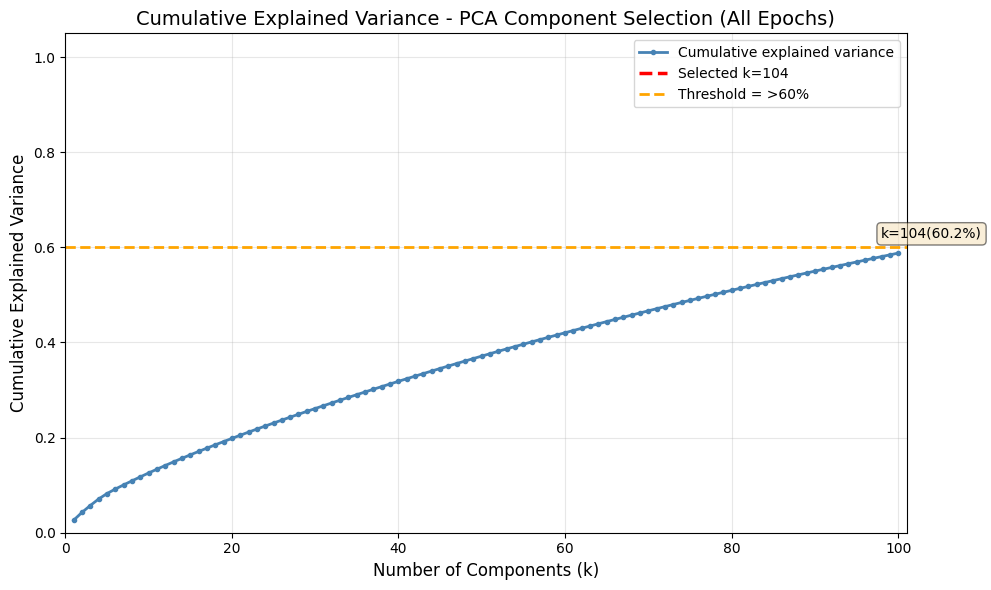

✓ Cumulative variance plot: k=104 selected at >60% threshold
  To adjust: change 'variance_threshold' variable (currently 0.6)


In [59]:

# Visualize cumulative explained variance and threshold in a clean format
fig, ax = plt.subplots(figsize=(10, 6))

# Plot cumulative explained variance
ax.plot(
    range(1, min(101, n_components + 1)),
    cumulative_variance[:min(100, n_components)],
    marker='o', markersize=3, linewidth=2,
    label='Cumulative explained variance', color='steelblue'
)

# Mark selected k with vertical line
ax.axvline(
    x=elbow_k, color='red', linestyle='--', linewidth=2.5,
    label=f'Selected k={elbow_k}'
)
# Mark threshold line
ax.axhline(
    y=variance_threshold, color='orange', linestyle='--',
    linewidth=2, label=f'Threshold = >{int(variance_threshold*100)}%'
)

# Add annotation at intersection
annotation_text = f'k={elbow_k}({cumulative_variance[elbow_k-1]*100:.1f}%)'
ax.text(
    elbow_k, variance_threshold + 0.02,
    annotation_text,
    fontsize=10, ha='center',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

# Formatting axes and plot
ax.set_xlabel('Number of Components (k)', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax.set_title('Cumulative Explained Variance - PCA Component Selection (All Epochs)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, min(101, n_components + 1))
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"✓ Cumulative variance plot: k={elbow_k} selected at >{int(variance_threshold*100)}% threshold")
print(f"  To adjust: change 'variance_threshold' variable (currently {variance_threshold})")


In [60]:
# Extract PCA components with k_source components (time × neuron PCA)
k_source = int(elbow_k)  # Rename for clarity - ensure int
max_k_source = min(T_all_source, n_neurons_source)

# Cap k_source at max allowed
if k_source > max_k_source:
    print(f"Warning: k_source={k_source} exceeds max allowed ({max_k_source}). Capping to {max_k_source}.")
    k_source = max_k_source

print("=== Extracting PCA Components ===")
print(f"Selected k_source: {k_source} components")
print(f"  Matrix shape: {X_source.shape} (time bins={T_all_source}, neurons={n_neurons_source})")
print(f"  Max k allowed: {max_k_source}")

# Run PCA on full matrix with k_source components
pca_source_k = compute_pca(X_source, n_components=k_source)

# Components: neuron weights (k_source × n_neurons)
principal_components_source = pca_source_k['components']

# Scores: latent activity over time (time bins × k_source)
scores_source = transform_pca(X_source, pca_source_k)

# Use latent time series (k_source × time bins) for downstream regression/null-space
scores_source_full = scores_source.T

print("=== Source PCA Components & Scores ===")
print(f"Principal components (neuron weights) shape: {principal_components_source.shape} (k_source × n_neurons)")
print(f"Scores shape: {scores_source.shape} (time bins × k_source)")
print(f"Latent time series shape: {scores_source_full.shape} (k_source × time bins)")

print("Explained variance (k_source components):")
total_var = pca_source_k['explained_variance_ratio'].sum()
print(f"  Total: {total_var:.4f} ({total_var*100:.2f}%)")
print(f"  Per component:")
for i in range(min(k_source, 10)):
    ev = pca_source_k['explained_variance_ratio'][i]
    print(f"    PC{i+1}: {ev:.4f} ({ev*100:.2f}%)")

# Store for later steps
pca_model_source = pca_source_k           # PCA model dictionary (time × neuron)
k_components_source = k_source
pc_matrix_source = scores_source_full     # k_source × time bins (used downstream)
score_matrix_source = scores_source       # time bins × k_source


=== Extracting PCA Components ===
Selected k_source: 104 components
  Matrix shape: (1650, 309) (time bins=1650, neurons=309)
  Max k allowed: 309
=== Source PCA Components & Scores ===
Principal components (neuron weights) shape: (104, 309) (k_source × n_neurons)
Scores shape: (1650, 104) (time bins × k_source)
Latent time series shape: (104, 1650) (k_source × time bins)
Explained variance (k_source components):
  Total: 0.6023 (60.23%)
  Per component:
    PC1: 0.0262 (2.62%)
    PC2: 0.0164 (1.64%)
    PC3: 0.0145 (1.45%)
    PC4: 0.0136 (1.36%)
    PC5: 0.0115 (1.15%)
    PC6: 0.0095 (0.95%)
    PC7: 0.0087 (0.87%)
    PC8: 0.0085 (0.85%)
    PC9: 0.0084 (0.84%)
    PC10: 0.0082 (0.82%)


In [61]:

# Store and summarize source PCA results (formatted output)
print("=== Stored Source PCA Results ===")
print(f"  k_source: {k_components_source}")
print(f"  Latent time series (pc_matrix_source) shape: {pc_matrix_source.shape}")
print(f"  Scores matrix shape (time × k): {score_matrix_source.shape}")
print(f"  Neuron-weight matrix shape: {pca_model_source['components'].shape}")
print(f"  Explained variance ratio: {pca_model_source['explained_variance_ratio']}")
print(f"  Cumulative variance (up to k_source): {np.cumsum(pca_model_source['explained_variance_ratio'])[-1]:.4f}")

print("✓ Source PCA results stored and ready.")
print(f"  - Components compress neurons; pc_matrix_source provides latent activity over time")
print(f"  - Next: run target PCA (Section 7) with k_target = k_source // 2")


=== Stored Source PCA Results ===
  k_source: 104
  Latent time series (pc_matrix_source) shape: (104, 1650)
  Scores matrix shape (time × k): (1650, 104)
  Neuron-weight matrix shape: (104, 309)
  Explained variance ratio: [0.02622022 0.01644708 0.01449242 0.01364161 0.01145864 0.00948822
 0.00874925 0.00849655 0.00836799 0.00819927 0.00796029 0.00778186
 0.00764497 0.00741505 0.00728934 0.00714158 0.00700147 0.00694859
 0.00676574 0.00675806 0.00664394 0.00655813 0.00644058 0.0063417
 0.00629174 0.00622709 0.00617992 0.00610267 0.00603766 0.00598799
 0.00593786 0.00587356 0.00583761 0.00577828 0.00576482 0.00571274
 0.00565528 0.00563499 0.00554435 0.00549325 0.00548056 0.00541972
 0.00541261 0.0053384  0.00530898 0.00527297 0.00525218 0.00521816
 0.00517913 0.00513928 0.00510401 0.00508579 0.00500439 0.00493879
 0.00488808 0.00487282 0.00482709 0.00480155 0.00479908 0.0047451
 0.00473359 0.00471634 0.00470934 0.00467375 0.00463277 0.00458388
 0.004561   0.00455298 0.00448341 0.00446

## 7. PCA Analysis (Target)

Run PCA on the target subset matrix (`firing_rate_normalized_target`) using k_target = k_source / 2.

**Naming Convention:**
- `firing_rate_normalized_target`: Subset matrix containing only units from selected target brain regions
- `firing_rate_normalized`: Full matrix with all units (NOT used in this section)
- `k_target`: Number of PCA components for target (k_source / 2)

**PCA Configuration:**
- Rows = units, columns = condition × time-bin features
- Components capture maximal variance (no demixing)


In [62]:

# Determine k for target matrix: 1/2 of source matrix k
# NOTE: PCA on time × neurons (transpose) mirrors source logic
k_source = int(k_components_source)  # k from source PCA (Section 6) - ensure int
k_target = int(max(1, k_source // 2))  # Target k is 1/2 of source k (minimum 1) - ensure int

# Build time-by-neuron matrix for target
X_target = firing_rate_normalized_target.T  # shape: (total_time_bins, n_neurons_target)
T_all_target, n_neurons_target = X_target.shape

# Check constraint: n_components <= min(n_samples, n_features)
max_k_target = min(T_all_target, n_neurons_target)

# Cap k_target at max allowed
if k_target > max_k_target:
    print(f"Warning: k_target={k_target} exceeds max allowed ({max_k_target}). Capping to {max_k_target}.")
    k_target = max_k_target

print("=== Target Matrix PCA Setup ===")
print(f"Source matrix k (from Section 6): {k_source}")
print(f"Target matrix k: {k_target} (1/2 of source k, capped at max)")
print(f"Target matrix shape (time bins × neurons): {X_target.shape}")
print(f"  Time bins: {T_all_target}, Neurons: {n_neurons_target}")
print(f"  Max k allowed: {max_k_target}")


=== Target Matrix PCA Setup ===
Source matrix k (from Section 6): 104
Target matrix k: 52 (1/2 of source k, capped at max)
Target matrix shape (time bins × neurons): (1650, 241)
  Time bins: 1650, Neurons: 241
  Max k allowed: 241


In [63]:

# Run PCA on target matrix with k_target components (time × neuron PCA)
print(f"Running PCA on target matrix with k_target={k_target} components...")

# Run PCA on full matrix with k_target components
pca_target_full = compute_pca(X_target, n_components=k_target)

# Components: neuron weights (k_target × n_neurons_target)
principal_components_target = pca_target_full['components']

# Scores: latent activity over time (time bins × k_target)
scores_target = transform_pca(X_target, pca_target_full)

# Use latent time series (k_target × time bins) for downstream regression/null-space
scores_target_full = scores_target.T

print("=== Target Matrix PCA Results ===")
print(f"Neuron-weight matrix shape: {principal_components_target.shape} (k_target × n_neurons_target)")
print(f"Scores shape: {scores_target.shape} (time bins × k_target)")
print(f"Latent time series shape: {scores_target_full.shape} (k_target × time bins)")

print("Explained variance (k_target components):")
print(f"  Total (k_target components): {pca_target_full['explained_variance_ratio'].sum():.4f} ({pca_target_full['explained_variance_ratio'].sum()*100:.2f}%)")
print(f"  Per component:")
for i in range(min(k_target, 10)):
    print(f"    PC{i+1}: {pca_target_full['explained_variance_ratio'][i]:.4f} "
          f"({pca_target_full['explained_variance_ratio'][i]*100:.2f}%)")

print(f"✓ Target matrix PCA completed: shape ({k_target}, {scores_target_full.shape[1]})")


Running PCA on target matrix with k_target=52 components...
=== Target Matrix PCA Results ===
Neuron-weight matrix shape: (52, 241) (k_target × n_neurons_target)
Scores shape: (1650, 52) (time bins × k_target)
Latent time series shape: (52, 1650) (k_target × time bins)
Explained variance (k_target components):
  Total (k_target components): 0.3947 (39.47%)
  Per component:
    PC1: 0.0118 (1.18%)
    PC2: 0.0101 (1.01%)
    PC3: 0.0099 (0.99%)
    PC4: 0.0097 (0.97%)
    PC5: 0.0095 (0.95%)
    PC6: 0.0093 (0.93%)
    PC7: 0.0091 (0.91%)
    PC8: 0.0090 (0.90%)
    PC9: 0.0089 (0.89%)
    PC10: 0.0087 (0.87%)
✓ Target matrix PCA completed: shape (52, 1650)


In [64]:

# Store target PCA results
print("=== Stored Target PCA Results ===")
print(f"  k_target: {k_target}")
print(f"  Latent time series (pc_matrix_target) shape: {scores_target_full.shape}")
print(f"  Scores matrix (time × k): {scores_target.shape}")
print(f"  Neuron-weight matrix: shape {principal_components_target.shape}")
print(f"  Explained variance ratio: {pca_target_full['explained_variance_ratio']}")

# Store for later use
pca_model_target = pca_target_full  # Store PCA model (time × neuron)
k_components_target = k_target
pc_matrix_target = scores_target_full  # (k_target, time bins) - latent activity for downstream
score_matrix_target = scores_target  # (time bins, k_target)

print("✓ Target PCA results stored")
print(f"  Components span full matrix (all epochs)")
print(f"  Comparison: Source k={k_source}, Target k={k_target} (target = source / 2)")


=== Stored Target PCA Results ===
  k_target: 52
  Latent time series (pc_matrix_target) shape: (52, 1650)
  Scores matrix (time × k): (1650, 52)
  Neuron-weight matrix: shape (52, 241)
  Explained variance ratio: [0.01176025 0.01014335 0.0098503  0.0097015  0.00948792 0.00930002
 0.00913928 0.00899613 0.00885677 0.00872201 0.00859138 0.00852039
 0.00848072 0.00833994 0.00817206 0.00812449 0.00800158 0.00790763
 0.00783165 0.00780773 0.00775589 0.00763    0.00758716 0.00753635
 0.0074127  0.00734985 0.00733258 0.00728698 0.00717812 0.00711516
 0.00701893 0.00696182 0.00694957 0.00688885 0.00682416 0.00676775
 0.00670068 0.00664754 0.00660502 0.00656098 0.00645702 0.00643415
 0.00639676 0.00635902 0.0062969  0.00624486 0.00619911 0.00616331
 0.00612976 0.00608845 0.00606652 0.00602857]
✓ Target PCA results stored
  Components span full matrix (all epochs)
  Comparison: Source k=104, Target k=52 (target = source / 2)


## 8. Ridge Regression for Null Space Estimation

Estimate the mapping matrix W from regression epoch to projection epoch PCA components using ridge regression, trained only on regression epoch columns.


In [65]:

# Step 1: Verify Regression/Projection Index Vectors
# Use existing idx_regression (regression epoch) and idx_project (projection epoch) from Section 4

print("=== Regression/Projection Index Vectors ===")
print(f"Total columns in combined matrix: {firing_rate_combined.shape[1]}")
print(f"  Regression epoch (idx_regression): {idx_regression.sum()} columns")
print(f"  Projection epoch (idx_project): {idx_project.sum()} columns")
print(f"Verification:")
print(f"  idx_project + idx_regression should equal all True: {(idx_project | idx_regression).all()}")
print(f"  No overlap: {(idx_project & idx_regression).sum() == 0}")
print(f"✓ Index vectors ready:")
print(f"  idx_regression: regression epoch columns")
print(f"  idx_project: projection epoch columns")


=== Regression/Projection Index Vectors ===
Total columns in combined matrix: 1650
  Regression epoch (idx_regression): 400 columns
  Projection epoch (idx_project): 1250 columns
Verification:
  idx_project + idx_regression should equal all True: True
  No overlap: True
✓ Index vectors ready:
  idx_regression: regression epoch columns
  idx_project: projection epoch columns


In [66]:

# Step 2: Extract Training Matrices
# Training uses only regression epoch columns

# Extract SOURCE latent trajectories (k_source × time bins)
N_train = pc_matrix_source[:, idx_regression]

# Extract TARGET latent trajectories (k_target × time bins)
M_train = pc_matrix_target[:, idx_regression]

print("=== Training Matrices ===")
print(f"N_train (SOURCE latent, regression epoch columns): shape {N_train.shape}")
print(f"  k_source: {N_train.shape[0]} (should be {k_components_source})")
print(f"  num_regression_cols: {N_train.shape[1]}")
print(f"M_train (TARGET latent, regression epoch columns): shape {M_train.shape}")
print(f"  k_target: {M_train.shape[0]} (should be {k_components_target})")
print(f"  num_regression_cols: {M_train.shape[1]}")

print(f"✓ Training matrices extracted (using regression epoch columns only)")


=== Training Matrices ===
N_train (SOURCE latent, regression epoch columns): shape (104, 400)
  k_source: 104 (should be 104)
  num_regression_cols: 400
M_train (TARGET latent, regression epoch columns): shape (52, 400)
  k_target: 52 (should be 52)
  num_regression_cols: 400
✓ Training matrices extracted (using regression epoch columns only)


In [67]:
# Step 3: Implement Ridge Regression
# Ridge regression: M ≈ W * N
# W = (M_train @ N_train.T) @ inv(N_train @ N_train.T + lam * I_k_source)
# Shape: (k_target, k_source)

# Set ridge regularization parameter
lam = 0.1  # Can be adjusted/tuned

print("=== Ridge Regression Setup ===")
print(f"Ridge parameter λ: {lam}")
print(f"N_train shape: {N_train.shape} (k_source × num_fit_cols)")
print(f"M_train shape: {M_train.shape} (k_target × num_fit_cols)")

# Compute components of ridge regression formula
# N_train @ N_train.T: shape (k_source, k_source)
NNT = N_train @ N_train.T

# Identity matrix scaled by lambda: λ * I_k_source
I_k = lam * np.eye(N_train.shape[0])  # N_train.shape[0] = k_source

# Regularized covariance: N_train @ N_train.T + λ * I_k_source
regularized_cov = NNT + I_k

# Compute inverse: inv(N_train @ N_train.T + λ * I_k_source)
regularized_cov_inv = np.linalg.inv(regularized_cov)

# M_train @ N_train.T: shape (k_target, k_source)
MNT = M_train @ N_train.T

# Final W: shape (k_target, k_source)
W = (MNT @ regularized_cov_inv)

print(f"\n=== Ridge Regression Results ===")
print(f"W shape: {W.shape} (k_target × k_source)")
print(f"  k_target: {W.shape[0]}")
print(f"  k_source: {W.shape[1]}")
print(f"\nW statistics:")
print(f"  Mean: {W.mean():.6f}")
print(f"  Std: {W.std():.6f}")
print(f"  Min: {W.min():.6f}")
print(f"  Max: {W.max():.6f}")
print(f"\n✓ Ridge regression completed")


=== Ridge Regression Setup ===
Ridge parameter λ: 0.1
N_train shape: (104, 400) (k_source × num_fit_cols)
M_train shape: (52, 400) (k_target × num_fit_cols)

=== Ridge Regression Results ===
W shape: (52, 104) (k_target × k_source)
  k_target: 52
  k_source: 104

W statistics:
  Mean: -0.000891
  Std: 0.061182
  Min: -0.222061
  Max: 0.215149

✓ Ridge regression completed


In [68]:
# Step 4: Store and Verify Results

# Store W matrix and ridge parameter
W_matrix = W
lambda_ridge_value = lam

print("=== Stored Ridge Regression Results ===")
print(f"W_matrix shape: {W_matrix.shape} (k_target × k_source)")
print(f"  k_target: {W_matrix.shape[0]}")
print(f"  k_source: {W_matrix.shape[1]}")
print(f"\nLambda (ridge parameter): {lambda_ridge_value}")
print(f"\nW_matrix statistics:")
print(f"  Mean: {W_matrix.mean():.6f}")
print(f"  Std: {W_matrix.std():.6f}")
print(f"  Min: {W_matrix.min():.6f}")
print(f"  Max: {W_matrix.max():.6f}")

# Verify dimensions
assert W_matrix.shape == (k_components_target, k_components_source), \
    f"W_matrix shape mismatch: expected ({k_components_target}, {k_components_source}), got {W_matrix.shape}"

print(f"\n✓ W matrix stored and verified")
print(f"  Ready for null space projection")


=== Stored Ridge Regression Results ===
W_matrix shape: (52, 104) (k_target × k_source)
  k_target: 52
  k_source: 104

Lambda (ridge parameter): 0.1

W_matrix statistics:
  Mean: -0.000891
  Std: 0.061182
  Min: -0.222061
  Max: 0.215149

✓ W matrix stored and verified
  Ready for null space projection


## 9. SVD of Ridge Mapping (Potent & Null Bases)

Decompose the ridge-derived mapping `W_tilde` (from Section 8) to identify potent vs null subspaces on the source side, then project the source latent trajectories into those coordinates.

In [69]:
# SVD of ridge-derived mapping (W_tilde) to get potent/null bases in source space
W_tilde = W_matrix  # From Section 8 ridge regression

print("=== SVD of W_tilde (ridge mapping) ===")
print(f"W_tilde shape: {W_tilde.shape} (k_target × k_source)")

U, S, Vt = np.linalg.svd(W_tilde, full_matrices=True)
V = Vt.T  # Right singular vectors (source side)

print(f"U shape: {U.shape} (k_target × k_target)")
print(f"S length: {S.shape} (min(k_target, k_source), )")
print(f"V shape: {V.shape} (k_source × k_source) - right singular vectors")

# Select potent rank based on singular value magnitude (relative threshold)
singular_value_threshold = 1e-3 * S.max() if S.size > 0 else 0.0
r = int(np.sum(S > singular_value_threshold))

if r == 0 and S.size > 0:
    r = 1
    print("All singular values below threshold; forcing r=1 to keep leading potent dimension.")
elif S.size == 0:
    r = 0
    print("Warning: no singular values returned; setting r=0.")

V_pot = V[:, :r] if r > 0 else np.empty((V.shape[0], 0))
V_null = V[:, r:] if r < V.shape[1] else np.empty((V.shape[0], 0))
U_pot = U[:, :r] if r > 0 else np.empty((U.shape[0], 0))
U_null = U[:, r:] if r < U.shape[0] else np.empty((U.shape[0], 0))

print(f"Potent rank r: {r} (threshold = {singular_value_threshold:.6f})")
print(f"V_pot shape: {V_pot.shape} (k_source × r)")
print(f"V_null shape: {V_null.shape} (k_source × {V_null.shape[1]})")
print(f"U_pot shape: {U_pot.shape} (k_target × r)")
print(f"U_null shape: {U_null.shape} (k_target × {U_null.shape[1]})")


=== SVD of W_tilde (ridge mapping) ===
W_tilde shape: (52, 104) (k_target × k_source)
U shape: (52, 52) (k_target × k_target)
S length: (52,) (min(k_target, k_source), )
V shape: (104, 104) (k_source × k_source) - right singular vectors
Potent rank r: 52 (threshold = 0.001164)
V_pot shape: (104, 52) (k_source × r)
V_null shape: (104, 52) (k_source × 52)
U_pot shape: (52, 52) (k_target × r)
U_null shape: (52, 0) (k_target × 0)


In [70]:
# Project source latent activity into potent & null coordinates
N_lat = pc_matrix_source  # (k_source × T) latent source trajectories (all epochs/conditions)
T_all = N_lat.shape[1]

N_pot = V_pot.T @ N_lat if V_pot.size else np.empty((0, T_all))
N_null = V_null.T @ N_lat if V_null.size else np.empty((0, T_all))

# Store for downstream use
potent_basis_source = V_pot
null_basis_source = V_null
potent_timecourses = N_pot
null_timecourses = N_null

print("=== Potent/Null Projections (source latent space) ===")
print(f"N_lat shape: {N_lat.shape} (k_source × T)")
print(f"N_pot shape: {N_pot.shape} (r × T)")
print(f"N_null shape: {N_null.shape} ((k_source - r) × T)")
print("  Each row is one dimension's timecourse in potent/null space")
print("✓ Potent/null coordinates computed")


=== Potent/Null Projections (source latent space) ===
N_lat shape: (104, 1650) (k_source × T)
N_pot shape: (52, 1650) (r × T)
N_null shape: (52, 1650) ((k_source - r) × T)
  Each row is one dimension's timecourse in potent/null space
✓ Potent/null coordinates computed


## 10. Validate Null Space on Regression Epoch

Check that the null basis from Section 9 is (approximately) in the kernel of `W_tilde` by comparing potent vs null predictions during the regression window.

In [71]:
# Validate that null space is (approximately) the kernel of W_tilde on regression epoch
W_tilde = W_matrix
N_lat = pc_matrix_source           # Source latent trajectories (k_source × T)
M_lat = pc_matrix_target           # Target latent trajectories (k_target × T)
idx_reg = idx_regression           # Boolean mask for regression columns

# Regression-epoch slices
N_reg = N_lat[:, idx_reg]
N_pot_reg = potent_timecourses[:, idx_reg]
N_null_reg = null_timecourses[:, idx_reg]
M_reg = M_lat[:, idx_reg]

# Full prediction using all source dimensions
M_hat_full = W_tilde @ N_reg  # (k_target × T_reg)

# Potent-only prediction (project back to k_source before applying W_tilde)
N_reg_pot_only = V_pot @ N_pot_reg
M_hat_pot = W_tilde @ N_reg_pot_only

# Null-only prediction
N_reg_null_only = V_null @ N_null_reg
M_hat_null = W_tilde @ N_reg_null_only

# Helper metrics
frob = lambda x: float(np.linalg.norm(x, ord='fro'))

def r2_score_matrix(y_true, y_pred):
    resid = y_true - y_pred
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    if ss_tot == 0:
        return np.nan
    return 1.0 - ss_res / ss_tot

norm_pot = frob(M_hat_pot)
norm_null = frob(M_hat_null)
r2_pot = r2_score_matrix(M_reg, M_hat_pot)
r2_null = r2_score_matrix(M_reg, M_hat_null)
r2_full = r2_score_matrix(M_reg, M_hat_full)

print("=== Null-space validation (regression epoch) ===")
print(f"Shapes -> N_reg: {N_reg.shape}, M_reg: {M_reg.shape}, W_tilde: {W_tilde.shape}")
print(f"Potent rank r: {V_pot.shape[1]}, Null dims: {V_null.shape[1]}")
print(f"‖M_hat_pot‖_F:  {norm_pot:.6f}")
print(f"‖M_hat_null‖_F: {norm_null:.6f}")
print(f"R^2 (pot vs M_reg):  {r2_pot:.4f}")
print(f"R^2 (null vs M_reg): {r2_null:.4f}")
print(f"R^2 (full vs M_reg): {r2_full:.4f}")
print("Expectation: potent explains most variance; null explains ~none during regression epoch.")


=== Null-space validation (regression epoch) ===
Shapes -> N_reg: (104, 400), M_reg: (52, 400), W_tilde: (52, 104)
Potent rank r: 52, Null dims: 52
‖M_hat_pot‖_F:  15.416326
‖M_hat_null‖_F: 0.000000
R^2 (pot vs M_reg):  0.2715
R^2 (null vs M_reg): -0.0000
R^2 (full vs M_reg): 0.2715
Expectation: potent explains most variance; null explains ~none during regression epoch.


### Quick Diagnostics: W̃ Spectrum & Kernel Check

Brief checks to see if the null basis sits near the kernel of `W_tilde` and to inspect singular-value energy distribution.

In [72]:
# Quick diagnostics for W_tilde
W_tilde = W_matrix

# Spectrum summary
U_diag, S_diag, Vt_diag = np.linalg.svd(W_tilde, full_matrices=False)
energy = S_diag ** 2
energy_total = energy.sum() if energy.size else 0.0
cum_energy = np.cumsum(energy) / energy_total if energy_total > 0 else np.array([])

print("=== W_tilde singular values ===")
print(f"Top 10 singular values: {S_diag[:10]}")
if energy_total > 0:
    print(f"Energy captured by potent rank r={V_pot.shape[1]}: {cum_energy[min(V_pot.shape[1], len(cum_energy)) - 1]:.4f}" if V_pot.shape[1] > 0 else "Potent rank r=0")
    print(f"Total energy (Fro^2): {energy_total:.6f}")
else:
    print("No energy in W_tilde (all zeros?)")

# Kernel-ish check: push V_null through W_tilde
V_null_mat = V_null if V_null.size else np.empty((W_tilde.shape[1], 0))
V_pot_mat = V_pot if V_pot.size else np.empty((W_tilde.shape[1], 0))
null_push = W_tilde @ V_null_mat  # (k_target × null_dims)
pot_push = W_tilde @ V_pot_mat    # (k_target × r)

frob = lambda x: float(np.linalg.norm(x, ord='fro'))

print("=== Kernel check ===")
print(f"‖W_tilde @ V_null‖_F: {frob(null_push):.6f} (null dims={V_null_mat.shape[1]})")
print(f"‖W_tilde @ V_pot‖_F:  {frob(pot_push):.6f} (potent dims={V_pot_mat.shape[1]})")
print("Interpretation: null push should be near zero compared to potent push if kernel is captured.")


=== W_tilde singular values ===
Top 10 singular values: [1.16430885 1.10150808 1.05814105 1.01846205 0.96724118 0.93395872
 0.89666258 0.87613912 0.84524419 0.81921146]
Energy captured by potent rank r=52: 1.0000
Total energy (Fro^2): 20.247517
=== Kernel check ===
‖W_tilde @ V_null‖_F: 0.000000 (null dims=52)
‖W_tilde @ V_pot‖_F:  4.499724 (potent dims=52)
Interpretation: null push should be near zero compared to potent push if kernel is captured.


### Ridge Fit Sanity (Regression Epoch)

Check whether `W_tilde` explains variance in the target latent activity during the regression window.

In [73]:
# Ridge fit sanity on regression epoch
W_tilde = W_matrix
N_lat = pc_matrix_source
M_lat = pc_matrix_target
idx_reg = idx_regression

N_reg = N_lat[:, idx_reg]
M_reg = M_lat[:, idx_reg]
M_hat_reg = W_tilde @ N_reg

# Per-dimension R^2 and correlations
per_dim_r2 = []
per_dim_corr = []
for i in range(M_reg.shape[0]):
    y = M_reg[i]
    yhat = M_hat_reg[i]
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    per_dim_r2.append(r2)
    # correlation guard
    if np.std(y) == 0 or np.std(yhat) == 0:
        per_dim_corr.append(np.nan)
    else:
        per_dim_corr.append(np.corrcoef(y, yhat)[0, 1])

# Aggregate R^2
ss_res_full = float(np.sum((M_reg - M_hat_reg) ** 2))
ss_tot_full = float(np.sum((M_reg - M_reg.mean()) ** 2))
r2_full = np.nan if ss_tot_full == 0 else 1 - ss_res_full / ss_tot_full

print("=== Ridge fit sanity (regression epoch) ===")
print(f"M_reg shape: {M_reg.shape}, W_tilde: {W_tilde.shape}")
print(f"Aggregate R^2: {r2_full:.4f}")
print(f"Per-dim R^2 (first 10): {[round(x,4) if x==x else None for x in per_dim_r2[:10]]}")
print(f"Per-dim corr (first 10): {[round(x,4) if x==x else None for x in per_dim_corr[:10]]}")
print("Tip: if R^2 is near zero everywhere, consider tuning lambda or lowering potent rank threshold.")


=== Ridge fit sanity (regression epoch) ===
M_reg shape: (52, 400), W_tilde: (52, 104)
Aggregate R^2: 0.2715
Per-dim R^2 (first 10): [0.2687, 0.22, 0.2527, 0.2231, 0.2964, 0.2773, 0.2814, 0.2847, 0.2161, 0.2264]
Per-dim corr (first 10): [np.float64(0.5197), np.float64(0.4693), np.float64(0.5027), np.float64(0.4733), np.float64(0.5445), np.float64(0.5269), np.float64(0.5328), np.float64(0.5339), np.float64(0.4682), np.float64(0.4758)]
Tip: if R^2 is near zero everywhere, consider tuning lambda or lowering potent rank threshold.


## 11. Potent vs Null Variance & Decoding Across Epochs

Contrast potent/null activity and condition decoding across prep (projection) and regression (movement) epochs to illustrate the classic null-space story.

In [74]:
# Variance + decoding across projection vs regression epochs
N_lat = pc_matrix_source
idx_reg = idx_regression
idx_proj = idx_project  # projection epoch = prep/delay

# Variance helpers
var_sum = lambda arr: float(np.var(arr, axis=1).sum()) if arr.size else 0.0

# Epoch slices
N_pot_reg = N_pot[:, idx_reg]
N_null_reg = N_null[:, idx_reg]
N_pot_proj = N_pot[:, idx_proj]
N_null_proj = N_null[:, idx_proj]

var_pot_reg = var_sum(N_pot_reg)
var_null_reg = var_sum(N_null_reg)
var_pot_proj = var_sum(N_pot_proj)
var_null_proj = var_sum(N_null_proj)

print("=== Subspace variance by epoch ===")
print(f"Potent dims: {N_pot.shape[0]}, Null dims: {N_null.shape[0]}")
print(f"Regression epoch  -> var_pot: {var_pot_reg:.6f}, var_null: {var_null_reg:.6f}")
print(f"Projection epoch  -> var_pot: {var_pot_proj:.6f}, var_null: {var_null_proj:.6f}")
print("Expectation: movement/regression high in potent; projection/prep high in null or balanced.")

# Build condition labels per column
n_cols_total = N_lat.shape[1]
labels_all = np.array([f'col_{i}' for i in range(n_cols_total)], dtype=object)

if 'combined_group_info' in globals() and combined_group_info is not None:
    for name, sl in combined_group_info.items():
        labels_all[sl] = name
elif 'combined_column_labels' in globals() and combined_column_labels is not None and len(combined_column_labels) == n_cols_total:
    labels_all = np.array(combined_column_labels, dtype=object)

# Decoder helper

def decode_epoch(X, y, label):
    if X.size == 0:
        print(f"{label}: no dimensions; skipping")
        return np.nan, np.nan
    unique, counts = np.unique(y, return_counts=True)
    if len(unique) < 2 or counts.min() < 2:
        print(f"{label}: not enough classes or samples per class; skipping")
        return np.nan, np.nan
    try:
        from sklearn.linear_model import LogisticRegression
        from sklearn.model_selection import StratifiedKFold, cross_val_score
    except ImportError:
        print(f"{label}: scikit-learn not available; skipping decoding")
        return np.nan, np.nan
    n_splits = int(max(2, min(5, counts.min())))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    clf = LogisticRegression(max_iter=200, n_jobs=None)
    scores = cross_val_score(clf, X, y, cv=cv)
    return float(scores.mean()), float(scores.std())

# Projection epoch decoding
X_pot_proj = N_pot_proj.T
X_null_proj = N_null_proj.T
y_proj = labels_all[idx_proj]

# Regression epoch decoding
X_pot_reg = N_pot_reg.T
X_null_reg = N_null_reg.T
y_reg = labels_all[idx_reg]

proj_pot_acc, proj_pot_std = decode_epoch(X_pot_proj, y_proj, "Projection potent")
proj_null_acc, proj_null_std = decode_epoch(X_null_proj, y_proj, "Projection null")
reg_pot_acc, reg_pot_std = decode_epoch(X_pot_reg, y_reg, "Regression potent")
reg_null_acc, reg_null_std = decode_epoch(X_null_reg, y_reg, "Regression null")

print("=== Condition decoding (mean ± sd CV accuracy) ===")
print(f"Projection potent: {proj_pot_acc:.3f} ± {proj_pot_std:.3f}")
print(f"Projection null:   {proj_null_acc:.3f} ± {proj_null_std:.3f}")
print(f"Regression potent: {reg_pot_acc:.3f} ± {reg_pot_std:.3f}")
print(f"Regression null:   {reg_null_acc:.3f} ± {reg_null_std:.3f}")
print("Look for: projection/null > projection/potent; regression/potent > regression/null.")


=== Subspace variance by epoch ===
Potent dims: 52, Null dims: 52
Regression epoch  -> var_pot: 1.806791, var_null: 2.503340
Projection epoch  -> var_pot: 2.220276, var_null: 2.396066
Expectation: movement/regression high in potent; projection/prep high in null or balanced.
=== Condition decoding (mean ± sd CV accuracy) ===
Projection potent: 0.361 ± 0.019
Projection null:   0.342 ± 0.044
Regression potent: 0.430 ± 0.042
Regression null:   0.287 ± 0.049
Look for: projection/null > projection/potent; regression/potent > regression/null.


## 12. Visualizations (Potent vs Null)

Quick sanity plots: trajectories in potent/null spaces across projection vs regression epochs, regression prediction check, and decoding accuracy bars.

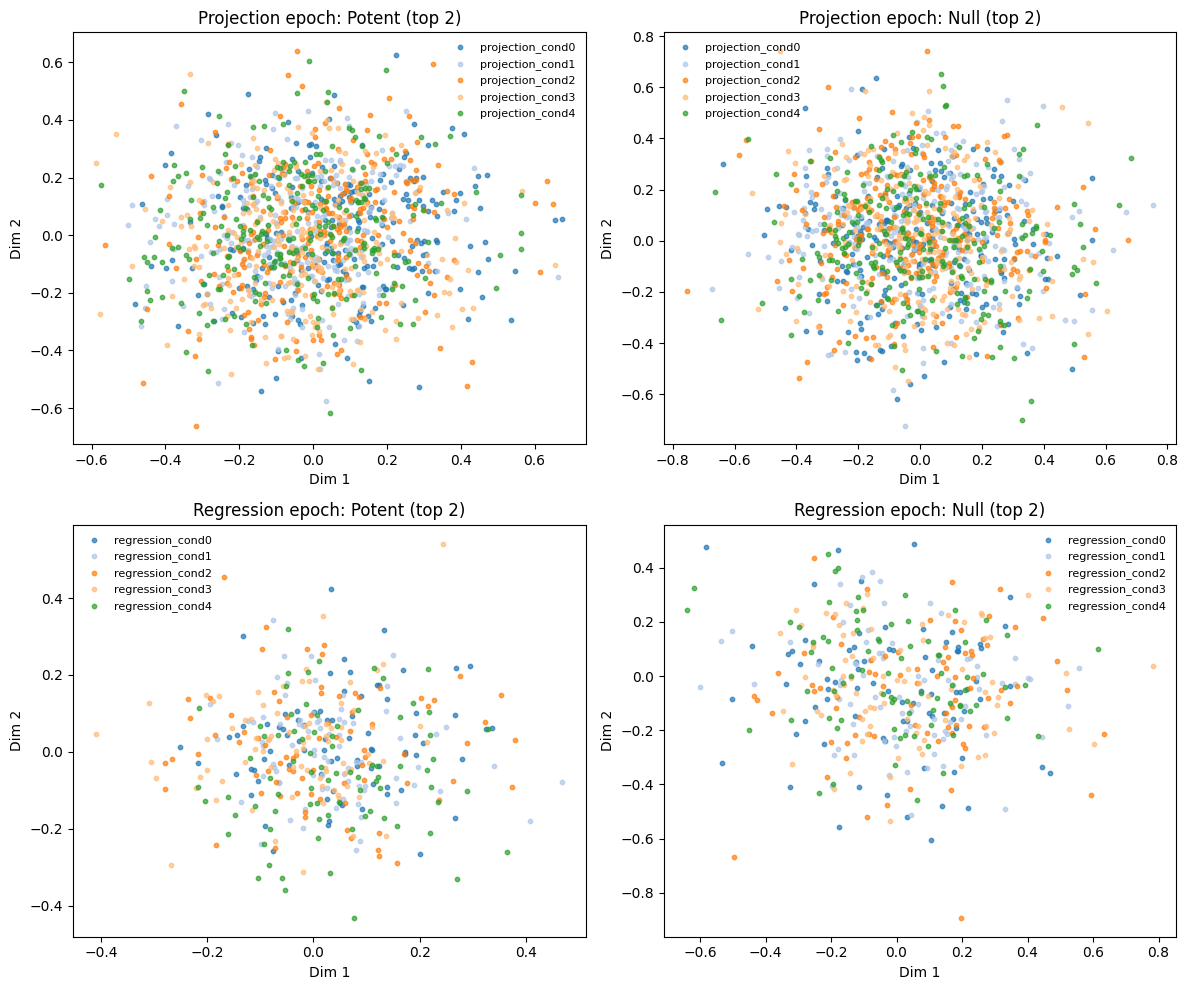

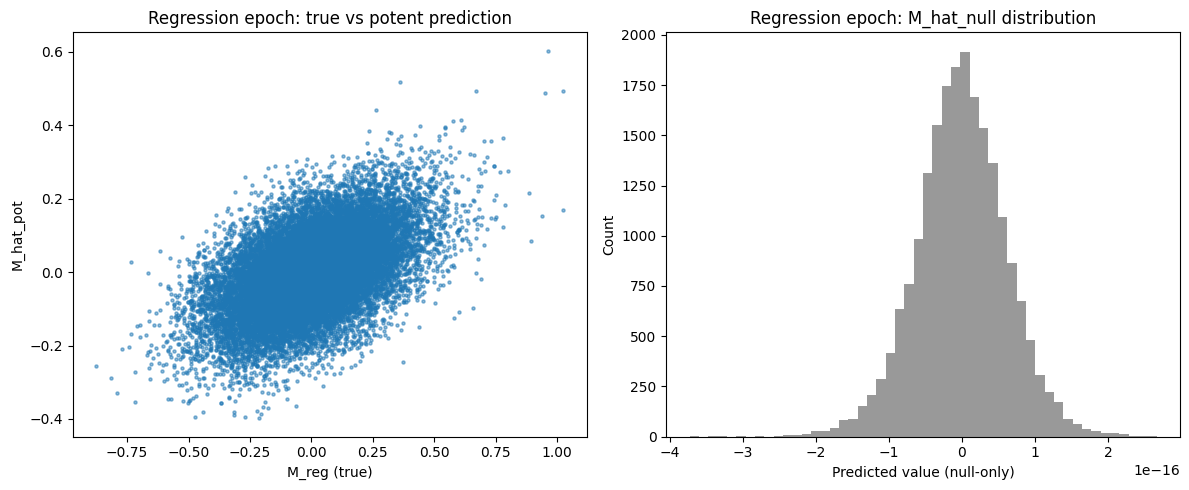

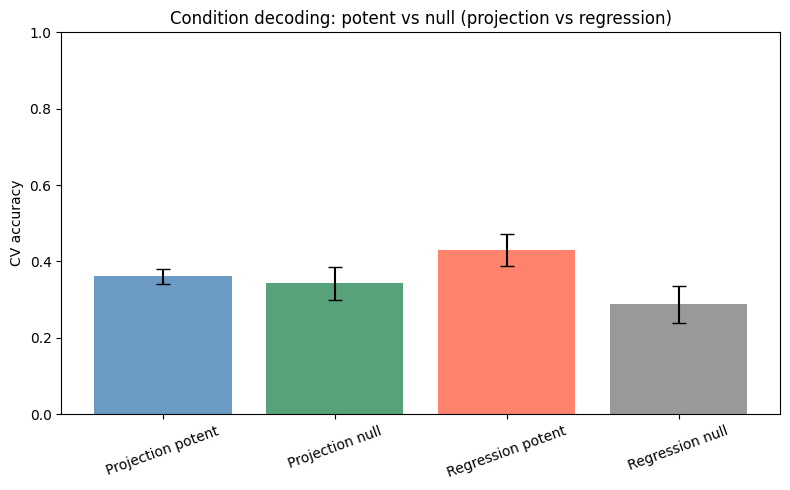

In [75]:
# Visualization helpers and plots
import matplotlib.pyplot as plt
from matplotlib import cm

# Label construction (reuse if already built)
n_cols_total = pc_matrix_source.shape[1]
labels_all = np.array([f'col_{i}' for i in range(n_cols_total)], dtype=object)
if 'combined_group_info' in globals() and combined_group_info is not None:
    for name, sl in combined_group_info.items():
        labels_all[sl] = name
elif 'combined_column_labels' in globals() and combined_column_labels is not None and len(combined_column_labels) == n_cols_total:
    labels_all = np.array(combined_column_labels, dtype=object)

# Epoch masks
idx_reg = idx_regression
idx_proj = idx_project

# --- 1) Trajectories in potent vs null (top 2 dims) ---
def plot_2d(X, labels, title, ax):
    if X.shape[0] < 2 or X.shape[1] == 0:
        ax.text(0.5, 0.5, 'Not enough dims/points', ha='center')
        ax.set_axis_off()
        return
    # Map labels to ints/colors
    uniq = np.unique(labels)
    color_map = {lab: cm.tab20(i % 20) for i, lab in enumerate(uniq)}
    for lab in uniq:
        mask = labels == lab
        ax.scatter(X[0, mask], X[1, mask], s=10, alpha=0.7, color=color_map[lab], label=str(lab))
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.set_title(title)
    ax.legend(fontsize=8, markerscale=1, frameon=False)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
plot_2d(N_pot[:, idx_proj], labels_all[idx_proj], 'Projection epoch: Potent (top 2)', axs[0, 0])
plot_2d(N_null[:, idx_proj], labels_all[idx_proj], 'Projection epoch: Null (top 2)', axs[0, 1])
plot_2d(N_pot[:, idx_reg], labels_all[idx_reg], 'Regression epoch: Potent (top 2)', axs[1, 0])
plot_2d(N_null[:, idx_reg], labels_all[idx_reg], 'Regression epoch: Null (top 2)', axs[1, 1])
plt.tight_layout()
plt.show()

# --- 2) Regression prediction check ---
try:
    M_reg  # ensure from Section 10
except NameError:
    M_reg = pc_matrix_target[:, idx_reg]
    M_hat_pot = W_matrix @ (V_pot @ N_pot[:, idx_reg])
    M_hat_null = W_matrix @ (V_null @ N_null[:, idx_reg])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(M_reg.ravel(), M_hat_pot.ravel(), s=5, alpha=0.5)
ax[0].set_xlabel('M_reg (true)')
ax[0].set_ylabel('M_hat_pot')
ax[0].set_title('Regression epoch: true vs potent prediction')

ax[1].hist(M_hat_null.ravel(), bins=50, color='gray', alpha=0.8)
ax[1].set_title('Regression epoch: M_hat_null distribution')
ax[1].set_xlabel('Predicted value (null-only)')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# --- 3) Decoding bar plot ---
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Projection potent', 'Projection null', 'Regression potent', 'Regression null']
means = [proj_pot_acc, proj_null_acc, reg_pot_acc, reg_null_acc]
errs = [proj_pot_std, proj_null_std, reg_pot_std, reg_null_std]
x = np.arange(len(labels))
ax.bar(x, means, yerr=errs, capsize=5, color=['steelblue', 'seagreen', 'tomato', 'gray'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel('CV accuracy')
ax.set_ylim(0, 1)
ax.set_title('Condition decoding: potent vs null (projection vs regression)')
plt.tight_layout()
plt.show()


## 11b. Potent vs Null Variance & Decoding Across Epochs (Target)
Mirror Section 11 but using target latent activity projected into the left singular vectors (target side) of the ridge mapping. This contrasts potent/null variance and decoding across projection (prep) vs regression (movement) epochs for the target population.

In [76]:
# Variance + decoding across projection vs regression epochs (target)
M_lat = pc_matrix_target
idx_reg = idx_regression
idx_proj = idx_project  # projection epoch = prep/delay

# Build target potent/null coordinates from left singular vectors
M_pot = U_pot.T @ M_lat if 'U_pot' in globals() and U_pot.size else np.empty((0, M_lat.shape[1]))
M_null = U_null.T @ M_lat if 'U_null' in globals() and U_null.size else np.empty((0, M_lat.shape[1]))

potent_basis_target = U_pot
null_basis_target = U_null
potent_timecourses_target = M_pot
null_timecourses_target = M_null

# Variance helpers
var_sum = lambda arr: float(np.var(arr, axis=1).sum()) if arr.size else 0.0

# Epoch slices
M_pot_reg = M_pot[:, idx_reg]
M_null_reg = M_null[:, idx_reg]
M_pot_proj = M_pot[:, idx_proj]
M_null_proj = M_null[:, idx_proj]

var_pot_reg_t = var_sum(M_pot_reg)
var_null_reg_t = var_sum(M_null_reg)
var_pot_proj_t = var_sum(M_pot_proj)
var_null_proj_t = var_sum(M_null_proj)

print("=== Target subspace variance by epoch ===")
print(f"Potent dims: {M_pot.shape[0]}, Null dims: {M_null.shape[0]}")
print(f"Regression epoch  -> var_pot: {var_pot_reg_t:.6f}, var_null: {var_null_reg_t:.6f}")
print(f"Projection epoch  -> var_pot: {var_pot_proj_t:.6f}, var_null: {var_null_proj_t:.6f}")
print("Expectation: movement/regression high in potent; projection/prep high in null or balanced (target side).")

# Build condition labels per column
n_cols_total = M_lat.shape[1]
labels_all = np.array([f'col_{i}' for i in range(n_cols_total)], dtype=object)

if 'combined_group_info' in globals() and combined_group_info is not None:
    for name, sl in combined_group_info.items():
        labels_all[sl] = name
elif 'combined_column_labels' in globals() and combined_column_labels is not None and len(combined_column_labels) == n_cols_total:
    labels_all = np.array(combined_column_labels, dtype=object)

# Decoder helper

def decode_epoch(X, y, label):
    if X.size == 0:
        print(f"{label}: no dimensions; skipping")
        return np.nan, np.nan
    unique, counts = np.unique(y, return_counts=True)
    if len(unique) < 2 or counts.min() < 2:
        print(f"{label}: not enough classes or samples per class; skipping")
        return np.nan, np.nan
    try:
        from sklearn.linear_model import LogisticRegression
        from sklearn.model_selection import StratifiedKFold, cross_val_score
    except ImportError:
        print(f"{label}: scikit-learn not available; skipping decoding")
        return np.nan, np.nan
    n_splits = int(max(2, min(5, counts.min())))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    clf = LogisticRegression(max_iter=200, n_jobs=None)
    scores = cross_val_score(clf, X, y, cv=cv)
    return float(scores.mean()), float(scores.std())

# Projection epoch decoding (target)
X_pot_proj_t = M_pot_proj.T
X_null_proj_t = M_null_proj.T
y_proj = labels_all[idx_proj]

# Regression epoch decoding (target)
X_pot_reg_t = M_pot_reg.T
X_null_reg_t = M_null_reg.T
y_reg = labels_all[idx_reg]

proj_pot_acc_t, proj_pot_std_t = decode_epoch(X_pot_proj_t, y_proj, "Projection potent (target)")
proj_null_acc_t, proj_null_std_t = decode_epoch(X_null_proj_t, y_proj, "Projection null (target)")
reg_pot_acc_t, reg_pot_std_t = decode_epoch(X_pot_reg_t, y_reg, "Regression potent (target)")
reg_null_acc_t, reg_null_std_t = decode_epoch(X_null_reg_t, y_reg, "Regression null (target)")

print("=== Target condition decoding (mean ± sd CV accuracy) ===")
print(f"Projection potent: {proj_pot_acc_t:.3f} ± {proj_pot_std_t:.3f}")
print(f"Projection null:   {proj_null_acc_t:.3f} ± {proj_null_std_t:.3f}")
print(f"Regression potent: {reg_pot_acc_t:.3f} ± {reg_pot_std_t:.3f}")
print(f"Regression null:   {reg_null_acc_t:.3f} ± {reg_null_std_t:.3f}")
print("Look for: projection/null > projection/potent; regression/potent > regression/null (target side).")


=== Target subspace variance by epoch ===
Potent dims: 52, Null dims: 0
Regression epoch  -> var_pot: 2.207000, var_null: 0.000000
Projection epoch  -> var_pot: 2.132767, var_null: 0.000000
Expectation: movement/regression high in potent; projection/prep high in null or balanced (target side).
Projection null (target): no dimensions; skipping
Regression null (target): no dimensions; skipping
=== Target condition decoding (mean ± sd CV accuracy) ===
Projection potent: 0.397 ± 0.027
Projection null:   nan ± nan
Regression potent: 0.518 ± 0.056
Regression null:   nan ± nan
Look for: projection/null > projection/potent; regression/potent > regression/null (target side).


## 12b. Visualizations (Potent vs Null, Target)
Sanity plots for the target potent/null spaces across projection vs regression epochs, plus decoding bars mirroring Section 12.

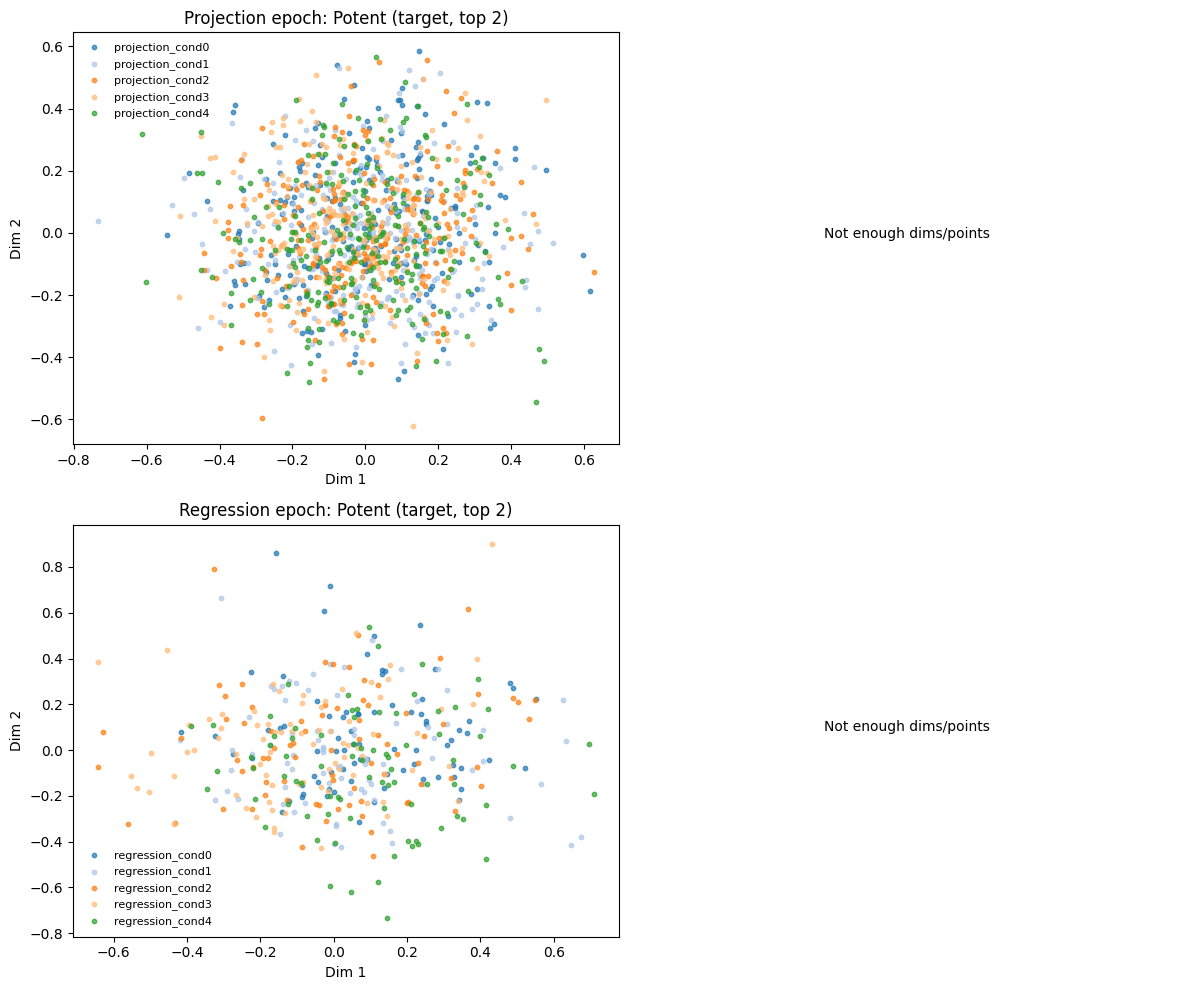

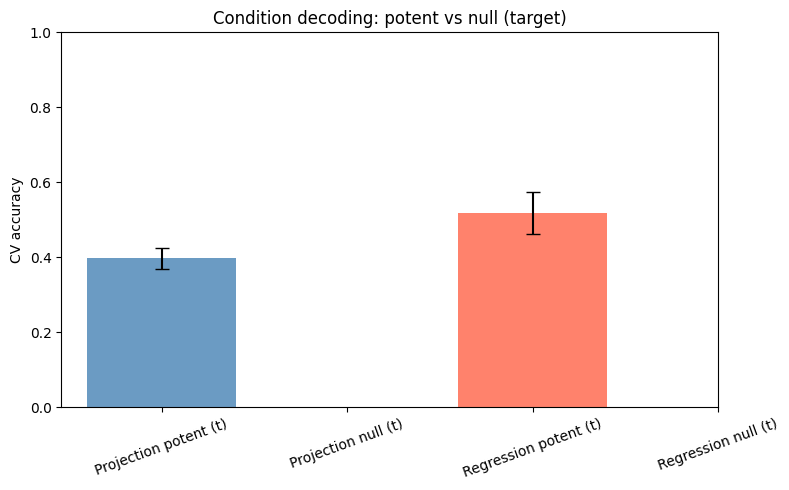

In [77]:
# Visualization for target potent/null spaces
import matplotlib.pyplot as plt
from matplotlib import cm

# Label construction (reuse if already built)
n_cols_total = pc_matrix_target.shape[1]
labels_all = np.array([f'col_{i}' for i in range(n_cols_total)], dtype=object)
if 'combined_group_info' in globals() and combined_group_info is not None:
    for name, sl in combined_group_info.items():
        labels_all[sl] = name
elif 'combined_column_labels' in globals() and combined_column_labels is not None and len(combined_column_labels) == n_cols_total:
    labels_all = np.array(combined_column_labels, dtype=object)

# Epoch masks
idx_reg = idx_regression
idx_proj = idx_project

# --- 1) Trajectories in potent vs null (top 2 dims) ---
def plot_2d(X, labels, title, ax):
    if X.shape[0] < 2 or X.shape[1] == 0:
        ax.text(0.5, 0.5, 'Not enough dims/points', ha='center')
        ax.set_axis_off()
        return
    uniq = np.unique(labels)
    color_map = {lab: cm.tab20(i % 20) for i, lab in enumerate(uniq)}
    for lab in uniq:
        mask = labels == lab
        ax.scatter(X[0, mask], X[1, mask], s=10, alpha=0.7, color=color_map[lab], label=str(lab))
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.set_title(title)
    ax.legend(fontsize=8, markerscale=1, frameon=False)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
plot_2d(M_pot[:, idx_proj], labels_all[idx_proj], 'Projection epoch: Potent (target, top 2)', axs[0, 0])
plot_2d(M_null[:, idx_proj], labels_all[idx_proj], 'Projection epoch: Null (target, top 2)', axs[0, 1])
plot_2d(M_pot[:, idx_reg], labels_all[idx_reg], 'Regression epoch: Potent (target, top 2)', axs[1, 0])
plot_2d(M_null[:, idx_reg], labels_all[idx_reg], 'Regression epoch: Null (target, top 2)', axs[1, 1])
plt.tight_layout()
plt.show()

# --- 2) Decoding bar plot (target) ---
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Projection potent (t)', 'Projection null (t)', 'Regression potent (t)', 'Regression null (t)']
means = [proj_pot_acc_t, proj_null_acc_t, reg_pot_acc_t, reg_null_acc_t]
errs = [proj_pot_std_t, proj_null_std_t, reg_pot_std_t, reg_null_std_t]
x = np.arange(len(labels))
ax.bar(x, means, yerr=errs, capsize=5, color=['steelblue', 'seagreen', 'tomato', 'gray'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel('CV accuracy')
ax.set_ylim(0, 1)
ax.set_title('Condition decoding: potent vs null (target)')
plt.tight_layout()
plt.show()
